# Group 3
Members: Jacob Heller, Nana Kwasi Owusu, Keith Woods, Joe Nguyen

# Current / Potential Data Sources

Cancer Imagine Archive: https://www.cancerimagingarchive.net/

BRISC 2025 (Brain Tumor MRI Dataset): https://www.kaggle.com/datasets/briscdataset/brisc2025

Brain Tumor Classification Dataset (contains paper and kaggle dataset): https://github.com/SartajBhuvaji/Brain-Tumor-Classification-DataSet/tree/master

Original Brain Scan MRI Dataset: https://www.kaggle.com/datasets/masoudnickparvar/brain-tumor-mri-dataset

# BRISC

Context

Dataset Contents
* 6000 T1-weighted MRI images
* Four classes: Glioma, Meningioma, Pituitary, No Tumor
* Pixel-wise segmentation masks that are physician and radiologist validated
* Three Anatomical Planes: Axial, Coronal, Sagittal
* Clean and stratfied training and testing data with 5,000 and 1,000 entries respectively for the split
* Classification for multi-class tumor identification
* Segmentation for pixel-wise tumor region annotation

Dataset Notes
* Classification folders have image-level labels that can be used for standard image classification
* Segmentation folders have paired MRI images, each with a corresponding binary mask
* The image and mask filenames are identical for correspondance with the exception of their file extension (.jpg for images vs. .png for masks)
* All of the images are T1-weighted slices

Data Entries
* Classification - 6000
  * train - 5000
    * glioma - 1147
      * axial - 347
      * coronal - 428
      * sagittal - 372
    * meningioma - 1329
      * axial - 423
      * coronal - 426
      * sagittal - 480
    * pituitary - 1457
      * axial - 428
      * coronal - 496
      * sagittal - 533
    * no tumor - 1067
      * axial - 352
      * coronal - 310
      * sagittal - 405
  * test - 1000
    * glioma - 254
      * axial - 85
      * coronal - 81
      * sagittal - 88
    * meningioma - 306
      * axial - 134
      * coronal - 89
      * sagittal - 83
    * pituitary - 300
      * axial - 116
      * coronal - 98
      * sagittal - 86
    * no tumor - 140
      * axial - 52
      * coronal - 48
      * sagittal - 40
* Segmentation - 4797
  * train
    * masks - 3933
    * images - 3933
  * test
    * masks - 860
    * images - 860
* Classification - Plane Totals
  * Train - 5000
    * Axial - 1550
    * Coronal - 1660
    * Saggital - 1790
  * Test - 1000
    * Axial - 387
    * Coronal - 316
    * Sagittal - 297

Additional Notes
* Data reviewed and corrected by medical experts
* Balanced representation across planes as well as tumor classes

Applications for Senior Project
* Multi-class classification
* Binary tumor detection
* Cross-plane generalizaion
* Developing AI-assisted diagnosis tools




# Preprocessing Steps

- Load images - file paths, as well as all necessary libraries
- Resizing all images - e.g. to 512 by 512 pixels, if not
- Remove unwanted noise (for smoother image)
- Segmentation: specifically, semantic segmentation, which assigns a class label to each pixel in a given image; potentially involves morphology (see below)
- *Morphology (combined with Segmentation): further noise removal before instance segmentation (separating background from foreground objects); likely not necessary for our project's use case

# Model Selection (for later)



General steps to consider:
- Cross validation?

## Problem 1: Tumor Detection

Models:
- Artificial Neural Network (ANN) - Keras TensorFlow
  - Base model: input layer, 1 hidden layer, output layer
  - *Comparison models: four other models with incremented numbers of hidden layers (i.e. 2, 3, 4, and 5 hidden layers, respectively)

## Problem 2: Tumor Classification

Models:
- Professor and TA's suggestions
  - Logistic Regression
  - Decision Tree
  - Random Forest
  - ANN (Same as Problem 1)
  - CNN – more complicated

- Other models
  - K-Nearest Neighbor
  - Bayesian Neural Network
  - Linear Regression
  - Support Vector Model (SVM)
  - Ensemble model applications:
    - Bagging: Bootstrap aggregation of the same type of model
      - Training models in parallel on random data subsets, then combining by voting or averaging;
      - Reduces variance
      - Example: Random Forest is an extension of bootstrap aggregation of multiple decision trees
    - Boosting: sequential learning of same type of models
      - Train models sequentially, each one correcting the previous model's errors
      - Reduces bias
      - Example: XGBoost/AdaBoost
    - Stacking: Meta-learning
      - Use predictions of various base models as input features to a meta-model (to perform some form of aggregative classification)
      - Combines strengths of multiple model types
      - Example: Multi-level stacks; Logistic regression of base model outputs

\* Hyperparameters to be tested, but not all are necessary

# Loading & Resizing Images

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
import cv2
import tensorflow as tf
import keras

In [ ]:
from google.colab import drive
drive.mount('/content/drive')
from google.colab import files

Mounted at /content/drive


In [ ]:
!unzip /content/drive/MyDrive/INFO\ 442/archive.zip -d /content/drive/MyDrive/INFO\ 442/Dataset/

unzip:  cannot find or open /content/drive/MyDrive/INFO 442/archive.zip, /content/drive/MyDrive/INFO 442/archive.zip.zip or /content/drive/MyDrive/INFO 442/archive.zip.ZIP.


# EDA Classification

Classes found: ['glioma', 'meningioma', 'no_tumor', 'pituitary']
Total images: 6000 | Train: 5000 | Test: 1000

Filename class labels match folder names — good.


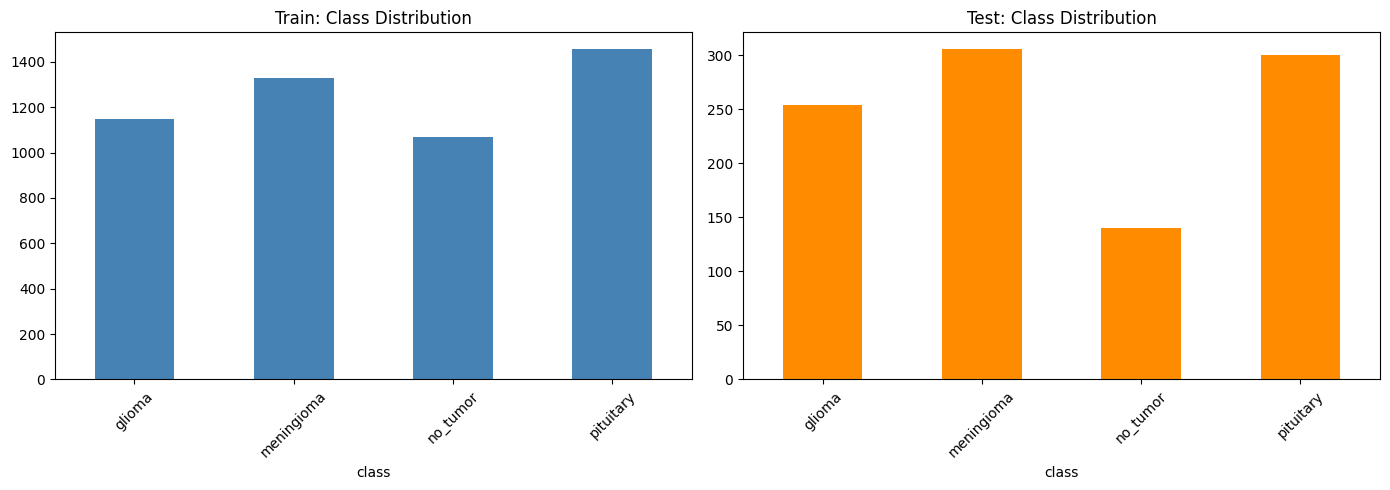


Class distribution:
 split       test  train  total  pct_of_total
class                                       
glioma       254   1147   1401         23.35
meningioma   306   1329   1635         27.25
no_tumor     140   1067   1207         20.12
pituitary    300   1457   1757         29.28

Class distribution by view:
 view        axial  coronal  sagittal
class                               
glioma        479      511       411
meningioma    560      512       563
no_tumor      404      358       445
pituitary     550      600       607


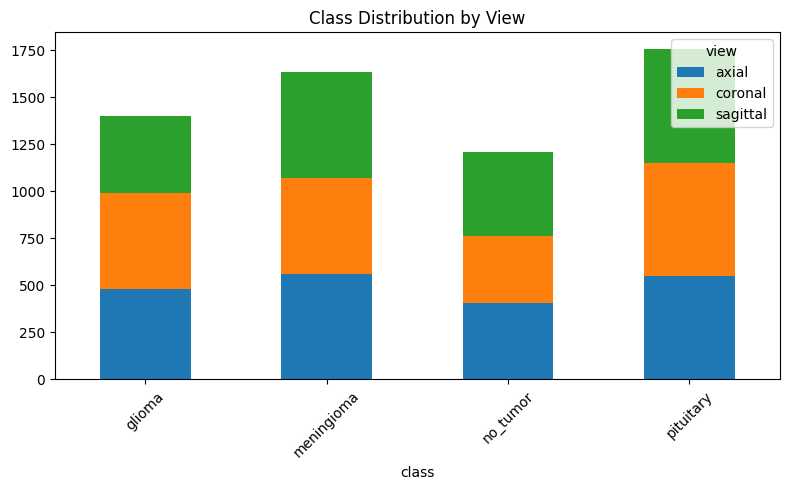


Imbalance ratio (max class / min class): 1.46


In [ ]:
import os
import re
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

#SET PATHS
BASE_DIR = Path("/content/drive/MyDrive/INFO442/brisc2025/classification_task")  # update to your actual path
TRAIN_DIR = BASE_DIR / "train"
TEST_DIR = BASE_DIR / "test"

CLASSES = sorted(os.listdir(TRAIN_DIR))
print("Classes found:", CLASSES)

#FILENAME PARSING
FILENAME_PATTERN = re.compile(
    r"brisc2025_(?P<split>train|test)_(?P<id>\d+)_(?P<class_code>gl|me|pi|no)_(?P<view_code>ax|co|sa)_(?P<modality>\w+)",
    re.IGNORECASE
)

CLASS_MAP = {"gl": "glioma", "me": "meningioma", "pi": "pituitary", "no": "no_tumor"}
VIEW_MAP = {"ax": "axial", "co": "coronal", "sa": "sagittal"}

def build_index(root_dir, split_name):
    records = []
    for cls_folder in CLASSES:
      if cls_folder == ".DS_Store":
        continue
      cls_dir = root_dir / cls_folder
      if not cls_dir.exists():
          continue
      for fname in os.listdir(cls_dir):
          if not fname.lower().endswith((".jpg", ".jpeg", ".png")):
              continue
          match = FILENAME_PATTERN.search(fname)
          if not match:
              print(f"Warning: filename didn't match pattern: {fname}")
              continue
          records.append({
              "path": str(cls_dir / fname),
              "class": CLASS_MAP[match.group("class_code").lower()],
              "split": split_name,
              "view": VIEW_MAP[match.group("view_code").lower()],
              "modality": match.group("modality").lower(),
              "patient_id": match.group("id")
          })
    return pd.DataFrame(records)

train_df = build_index(TRAIN_DIR, "train")
test_df = build_index(TEST_DIR, "test")
full_df = pd.concat([train_df, test_df], ignore_index=True)

print(f"Total images: {len(full_df)} | Train: {len(train_df)} | Test: {len(test_df)}")

# sanity check: filename class vs folder name
full_df["folder_class"] = full_df["path"].apply(lambda p: Path(p).parent.name)
mismatch = full_df[full_df["class"] != full_df["folder_class"]]
if len(mismatch) > 0:
    print(f"\nWARNING: {len(mismatch)} files have a filename class that doesn't match their folder name.")
    print(mismatch[["path", "class", "folder_class"]].head())
else:
    print("\nFilename class labels match folder names — good.")

#CLASS DISTRIBUTION: TRAIN VS TEST
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
train_df["class"].value_counts().sort_index().plot(kind="bar", ax=axes[0], color="steelblue")
axes[0].set_title("Train: Class Distribution")
axes[0].tick_params(axis='x', rotation=45)

test_df["class"].value_counts().sort_index().plot(kind="bar", ax=axes[1], color="darkorange")
axes[1].set_title("Test: Class Distribution")
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

#CLASS DISTRIBUTION TABLE
dist_table = pd.crosstab(full_df["class"], full_df["split"])
dist_table["total"] = dist_table.sum(axis=1)
dist_table["pct_of_total"] = (dist_table["total"] / dist_table["total"].sum() * 100).round(2)
print("\nClass distribution:\n", dist_table)

#CLASS DISTRIBUTION BY VIEW
view_table = pd.crosstab(full_df["class"], full_df["view"])
print("\nClass distribution by view:\n", view_table)

view_table.plot(kind="bar", stacked=True, figsize=(8, 5))
plt.title("Class Distribution by View")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

#IMBALANCE CHECK
imbalance_ratio = dist_table["total"].max() / dist_table["total"].min()
print(f"\nImbalance ratio (max class / min class): {imbalance_ratio:.2f}")

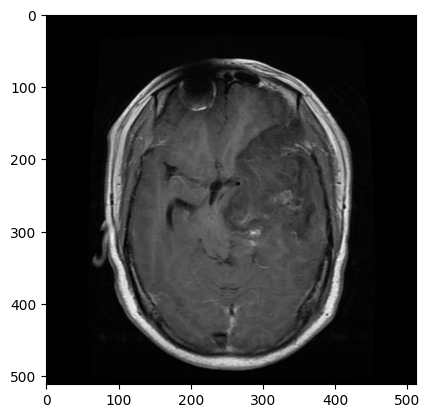

In [ ]:
from PIL import Image
import matplotlib.pyplot as plt

img = Image.open('/content/drive/MyDrive/INFO442/brisc2025/segmentation_task/train/images/brisc2025_train_00001_gl_ax_t1.jpg')

plt.imshow(img)

# Logistic Regression

#### Setup (Using Image Size 128)

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.decomposition import PCA
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

results = {}
IMG_SIZE = 128

def load_images(df, view=None, img_size=IMG_SIZE):
    if view is not None:
        df = df[df["view"] == view]
    X, y = [], []
    for _, row in df.iterrows():
        img = Image.open(row["path"]).convert("L").resize((img_size, img_size))
        X.append(np.array(img, dtype=np.float32).flatten() / 255.0)
        y.append(row["class"])
    return np.array(X), np.array(y)

## Logistic Regression - Axial

Train shape: (1595, 16384), Test shape: (398, 16384)
Variance explained by 100 PCs: 80.17%


/usr/local/lib/python3.13/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(



Classification Report:
               precision    recall  f1-score   support

      glioma       0.90      0.84      0.87        85
  meningioma       0.82      0.69      0.75       137
    no_tumor       0.59      0.83      0.69        52
   pituitary       0.92      0.97      0.94       124

    accuracy                           0.82       398
   macro avg       0.81      0.83      0.81       398
weighted avg       0.84      0.82      0.82       398



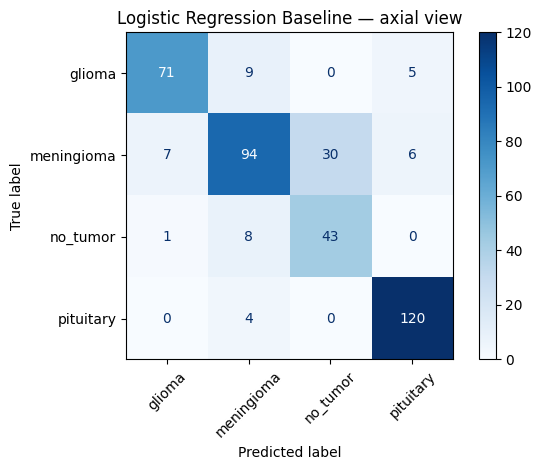

In [ ]:
VIEW_TO_USE = "axial"

X_train, y_train = load_images(train_df, view=VIEW_TO_USE)
X_test, y_test = load_images(test_df, view=VIEW_TO_USE)
print(f"Train shape: {X_train.shape}, Test shape: {X_test.shape}")

le = LabelEncoder()
y_train_enc = le.fit_transform(y_train)
y_test_enc = le.transform(y_test)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

pca = PCA(n_components=100, random_state=42)
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)
print(f"Variance explained by 100 PCs: {pca.explained_variance_ratio_.sum():.2%}")

clf_axial = LogisticRegression(max_iter=1000, class_weight="balanced", multi_class="multinomial")
clf_axial.fit(X_train_pca, y_train_enc)

y_pred_axial = clf_axial.predict(X_test_pca)
print("\nClassification Report:\n", classification_report(y_test_enc, y_pred_axial, target_names=le.classes_))

cm = confusion_matrix(y_test_enc, y_pred_axial)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le.classes_)
disp.plot(cmap="Blues", xticks_rotation=45)
plt.title(f"Logistic Regression Baseline — {VIEW_TO_USE} view")
plt.tight_layout()
plt.show()

results["axial"] = {
    "accuracy": (y_pred_axial == y_test_enc).mean(),
    "report": classification_report(y_test_enc, y_pred_axial, target_names=le.classes_, output_dict=True)
}

## Logistic Regression - Coronal

Train shape: (1676, 16384), Test shape: (305, 16384)
Variance explained by 100 PCs: 74.48%


/usr/local/lib/python3.13/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(



Classification Report:
               precision    recall  f1-score   support

      glioma       0.91      0.79      0.85        81
  meningioma       0.82      0.84      0.83        86
    no_tumor       0.83      1.00      0.91        48
   pituitary       0.99      0.98      0.98        90

    accuracy                           0.89       305
   macro avg       0.89      0.90      0.89       305
weighted avg       0.90      0.89      0.89       305



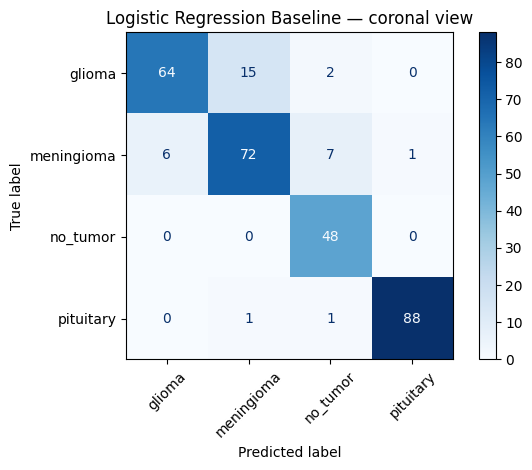

In [ ]:
VIEW_TO_USE = "coronal"

X_train, y_train = load_images(train_df, view=VIEW_TO_USE)
X_test, y_test = load_images(test_df, view=VIEW_TO_USE)
print(f"Train shape: {X_train.shape}, Test shape: {X_test.shape}")

le = LabelEncoder()
y_train_enc = le.fit_transform(y_train)
y_test_enc = le.transform(y_test)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

pca = PCA(n_components=100, random_state=42)
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)
print(f"Variance explained by 100 PCs: {pca.explained_variance_ratio_.sum():.2%}")

clf_coronal = LogisticRegression(max_iter=1000, class_weight="balanced", multi_class="multinomial")
clf_coronal.fit(X_train_pca, y_train_enc)

y_pred_coronal = clf_coronal.predict(X_test_pca)
print("\nClassification Report:\n", classification_report(y_test_enc, y_pred_coronal, target_names=le.classes_))

cm = confusion_matrix(y_test_enc, y_pred_coronal)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le.classes_)
disp.plot(cmap="Blues", xticks_rotation=45)
plt.title(f"Logistic Regression Baseline — {VIEW_TO_USE} view")
plt.tight_layout()
plt.show()

results["coronal"] = {
    "accuracy": (y_pred_coronal == y_test_enc).mean(),
    "report": classification_report(y_test_enc, y_pred_coronal, target_names=le.classes_, output_dict=True)
}

# Logistic Regression (64 x 64): Sagittal angle

Train shape: (1729, 16384), Test shape: (297, 16384)
Variance explained by 100 PCs: 68.04%


/usr/local/lib/python3.13/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(



Classification Report:
               precision    recall  f1-score   support

      glioma       0.73      0.88      0.80        88
  meningioma       0.88      0.67      0.76        83
    no_tumor       0.91      1.00      0.95        40
   pituitary       0.98      0.95      0.96        86

    accuracy                           0.86       297
   macro avg       0.87      0.88      0.87       297
weighted avg       0.87      0.86      0.86       297



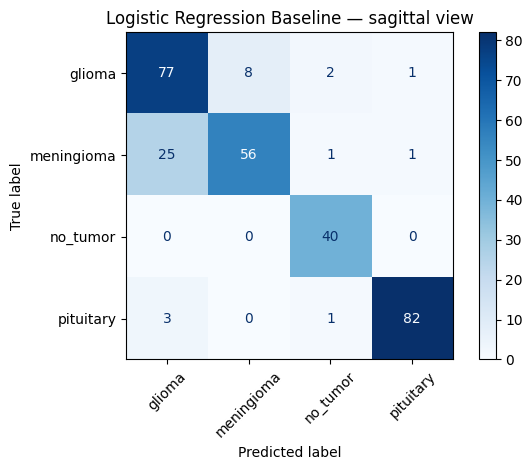

In [ ]:
VIEW_TO_USE = 'sagittal'

X_train, y_train = load_images(train_df, view=VIEW_TO_USE)
X_test, y_test = load_images(test_df, view=VIEW_TO_USE)
print(f"Train shape: {X_train.shape}, Test shape: {X_test.shape}")

le = LabelEncoder()
y_train_enc = le.fit_transform(y_train)
y_test_enc = le.transform(y_test)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

pca = PCA(n_components=100, random_state=42)
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)
print(f"Variance explained by 100 PCs: {pca.explained_variance_ratio_.sum():.2%}")

clf_sagittal = LogisticRegression(max_iter=1000, class_weight="balanced", multi_class="multinomial")
clf_sagittal.fit(X_train_pca, y_train_enc)

y_pred_sagittal = clf_sagittal.predict(X_test_pca)
print("\nClassification Report:\n", classification_report(y_test_enc, y_pred_sagittal, target_names=le.classes_))

cm = confusion_matrix(y_test_enc, y_pred_sagittal)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le.classes_)
disp.plot(cmap="Blues", xticks_rotation=45)
plt.title(f"Logistic Regression Baseline — {VIEW_TO_USE} view")
plt.tight_layout()
plt.show()

results["sagittal"] = {
    "accuracy": (y_pred_sagittal == y_test_enc).mean(),
    "report": classification_report(y_test_enc, y_pred_sagittal, target_names=le.classes_, output_dict=True)
}

In [ ]:
comparison = pd.DataFrame({
    view: {
        "accuracy": res["accuracy"],
        "macro_f1": res["report"]["macro avg"]["f1-score"],
        "weighted_f1": res["report"]["weighted avg"]["f1-score"],
    }
    for view, res in results.items()
}).T

print(comparison)

In [ ]:
'''
This code was used for Week 4 and has been updated since. New code that runs per angle was developed and can be seen above
'''

import numpy as np
from PIL import Image
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.decomposition import PCA
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

IMG_SIZE = 64
VIEW_TO_USE = "axial"

def load_images(df, view=None, img_size=IMG_SIZE):
    if view is not None:
        df = df[df["view"] == view]
    X, y = [], []
    for _, row in df.iterrows():
        img = Image.open(row["path"]).convert("L").resize((img_size, img_size))
        X.append(np.array(img, dtype=np.float32).flatten() / 255.0)
        y.append(row["class"])
    return np.array(X), np.array(y)

X_train, y_train = load_images(train_df, view=VIEW_TO_USE)
X_test, y_test = load_images(test_df, view=VIEW_TO_USE)
print(f"Train shape: {X_train.shape}, Test shape: {X_test.shape}")

le = LabelEncoder()
y_train_enc = le.fit_transform(y_train)
y_test_enc = le.transform(y_test)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

pca = PCA(n_components=100, random_state=42)
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)
print(f"Variance explained by 100 PCs: {pca.explained_variance_ratio_.sum():.2%}")

clf = LogisticRegression(max_iter=1000, class_weight="balanced", multi_class="multinomial")
clf.fit(X_train_pca, y_train_enc)

y_pred = clf.predict(X_test_pca)
print("\nClassification Report:\n", classification_report(y_test_enc, y_pred, target_names=le.classes_))

cm = confusion_matrix(y_test_enc, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le.classes_)
disp.plot(cmap="Blues", xticks_rotation=45)
plt.title(f"Logistic Regression Baseline — {VIEW_TO_USE} view")
plt.tight_layout()
plt.show()

# **Random Forest**

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.decomposition import PCA
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import numpy as np

rf_results = {}

def run_random_forest(view, n_estimators=300, max_depth=None, use_pca=True, n_components=100):
    X_train, y_train = load_images(train_df, view=view)
    X_test, y_test = load_images(test_df, view=view)
    print(f"[{view}] Train shape: {X_train.shape}, Test shape: {X_test.shape}")

    le = LabelEncoder()
    y_train_enc = le.fit_transform(y_train)
    y_test_enc = le.transform(y_test)

    if use_pca:
        pca = PCA(n_components=n_components, random_state=42)
        X_train_feat = pca.fit_transform(X_train)
        X_test_feat = pca.transform(X_test)
        print(f"Variance explained by {n_components} PCs: {pca.explained_variance_ratio_.sum():.2%}")
    else:
        X_train_feat, X_test_feat = X_train, X_test

    clf = RandomForestClassifier(
        n_estimators=n_estimators,
        max_depth=max_depth,
        class_weight="balanced",
        random_state=42,
        n_jobs=-1
    )
    clf.fit(X_train_feat, y_train_enc)

    y_pred = clf.predict(X_test_feat)
    print(f"\nClassification Report ({view}):\n",
          classification_report(y_test_enc, y_pred, target_names=le.classes_))

    cm = confusion_matrix(y_test_enc, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le.classes_)
    disp.plot(cmap="Greens", xticks_rotation=45)
    plt.title(f"Random Forest — {view} view")
    plt.tight_layout()
    plt.show()

    rf_results[view] = {
        "model": clf,
        "accuracy": (y_pred == y_test_enc).mean(),
        "report": classification_report(y_test_enc, y_pred, target_names=le.classes_, output_dict=True)
    }
    return clf, le

clf_axial_rf, le_axial = run_random_forest("axial")
clf_coronal_rf, le_coronal = run_random_forest("coronal")
clf_sagittal_rf, le_sagittal = run_random_forest("sagittal")

rf_comparison = pd.DataFrame({
    view: {
        "accuracy": res["accuracy"],
        "macro_f1": res["report"]["macro avg"]["f1-score"],
        "weighted_f1": res["report"]["weighted avg"]["f1-score"],
    }
    for view, res in rf_results.items()
}).T
print(rf_comparison)

# CNN Pipeline and Architecture

In [ ]:
# run this first to guarantee a clean slate — no stale model/graph left over
tf.keras.backend.clear_session()

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers, models
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

IMG_SIZE = 128
BATCH_SIZE = 32
VIEW_TO_USE = "axial"
NUM_CLASSES = full_df["class"].nunique()

# filter to one view, same as the logistic regression baseline
train_view_df = train_df[train_df["view"] == VIEW_TO_USE].reset_index(drop=True)
test_view_df = test_df[test_df["view"] == VIEW_TO_USE].reset_index(drop=True)

# carve out a validation set from train (stratified so class balance is preserved)
train_split_df, val_split_df = train_test_split(
    train_view_df, test_size=0.15, stratify=train_view_df["class"], random_state=42
)

print(f"Train: {len(train_split_df)} | Val: {len(val_split_df)} | Test: {len(test_view_df)}")

le = LabelEncoder()
le.fit(train_view_df["class"])
CLASS_NAMES = le.classes_
print("Classes:", CLASS_NAMES)

Train: 1355 | Val: 240 | Test: 398
Classes: ['glioma' 'meningioma' 'no_tumor' 'pituitary']


In [ ]:
#Building tf.data Pipeline
def load_and_preprocess(path, label):
    img = tf.io.read_file(path)
    img = tf.image.decode_jpeg(img, channels=1)  # grayscale, MRI scans don't need color channels
    img = tf.image.resize(img, [IMG_SIZE, IMG_SIZE])
    img = img / 255.0
    return img, label

def make_dataset(df, shuffle=False, augment=False):
    paths = df["path"].values
    labels = le.transform(df["class"].values)
    ds = tf.data.Dataset.from_tensor_slices((paths, labels))
    ds = ds.map(load_and_preprocess, num_parallel_calls=tf.data.AUTOTUNE)
    if augment:
        ds = ds.map(lambda x, y: (data_augmentation(x, training=True), y),
                    num_parallel_calls=tf.data.AUTOTUNE)
    if shuffle:
        ds = ds.shuffle(buffer_size=len(df))
    ds = ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
    return ds

# mild augmentation — MRI scans are position/orientation sensitive, so keep this conservative
data_augmentation = tf.keras.Sequential([
    layers.RandomRotation(0.05),
    layers.RandomZoom(0.05),
    layers.RandomContrast(0.1),
])

train_ds = make_dataset(train_split_df, shuffle=True, augment=True)
val_ds = make_dataset(val_split_df, shuffle=False, augment=False)
test_ds = make_dataset(test_view_df, shuffle=False, augment=False)

In [ ]:
#CNN Architecture
def build_cnn(img_size, num_classes):
    model = models.Sequential([
        layers.Input(shape=(img_size, img_size, 1)),

        layers.Conv2D(32, 3, padding="same", activation="relu"),
        layers.MaxPooling2D(),

        layers.Conv2D(64, 3, padding="same", activation="relu"),
        layers.MaxPooling2D(),

        layers.Conv2D(128, 3, padding="same", activation="relu"),
        layers.MaxPooling2D(),

        layers.GlobalAveragePooling2D(),
        layers.Dense(128, activation="relu"),
        layers.Dropout(0.4),
        layers.Dense(num_classes, activation="softmax"),
    ])
    return model

model = build_cnn(IMG_SIZE, NUM_CLASSES)
model.summary()

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 128, 128, 32)   │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 109,700 (428.52 KB)

 Trainable params: 109,700 (428.52 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/30
43/43 ━━━━━━━━━━━━━━━━━━━━ 228s 805ms/step - accuracy: 0.2716 - loss: 1.3851 - val_accuracy: 0.2667 - val_loss: 1.3800 - learning_rate: 1.0000e-04
Epoch 2/30
43/43 ━━━━━━━━━━━━━━━━━━━━ 5s 27ms/step - accuracy: 0.2745 - loss: 1.3768 - val_accuracy: 0.2667 - val_loss: 1.3702 - learning_rate: 1.0000e-04
Epoch 3/30
43/43 ━━━━━━━━━━━━━━━━━━━━ 7s 27ms/step - accuracy: 0.2819 - loss: 1.3656 - val_accuracy: 0.4250 - val_loss: 1.3567 - learning_rate: 1.0000e-04
Epoch 4/30
43/43 ━━━━━━━━━━━━━━━━━━━━ 8s 27ms/step - accuracy: 0.3314 - loss: 1.3446 - val_accuracy: 0.5167 - val_loss: 1.3238 - learning_rate: 1.0000e-04
Epoch 5/30
43/43 ━━━━━━━━━━━━━━━━━━━━ 7s 27ms/step - accuracy: 0.4089 - loss: 1.2852 - val_accuracy: 0.5500 - val_loss: 1.2499 - learning_rate: 1.0000e-04
Epoch 6/30
43/43 ━━━━━━━━━━━━━━━━━━━━ 5s 27ms/step - accuracy: 0.4782 - loss: 1.2166 - val_accuracy: 0.5708 - val_loss: 1.1699 - learning_rate: 1.0000e-04
Epoch 7/30
43/43 ━━━━━━━━━━━━━━━━━━━━ 7s 34ms/step - accuracy: 0.52

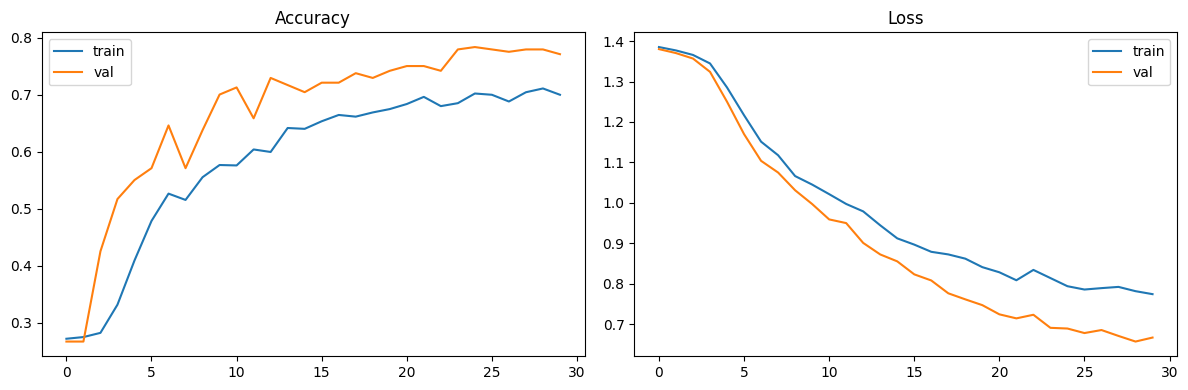

In [ ]:
#Training
callbacks = [
    tf.keras.callbacks.EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True),
    tf.keras.callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=3),
]

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=30,
    callbacks=callbacks
)

# training curves
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(history.history["accuracy"], label="train")
axes[0].plot(history.history["val_accuracy"], label="val")
axes[0].set_title("Accuracy")
axes[0].legend()

axes[1].plot(history.history["loss"], label="train")
axes[1].plot(history.history["val_loss"], label="val")
axes[1].set_title("Loss")
axes[1].legend()
plt.tight_layout()
plt.show()

13/13 ━━━━━━━━━━━━━━━━━━━━ 63s 5s/step
Classification Report (CNN, axial view):

              precision    recall  f1-score   support

      glioma       0.76      0.84      0.80        85
  meningioma       0.66      0.30      0.41       137
    no_tumor       0.35      0.69      0.46        52
   pituitary       0.82      0.92      0.87       124

    accuracy                           0.66       398
   macro avg       0.65      0.69      0.63       398
weighted avg       0.69      0.66      0.64       398



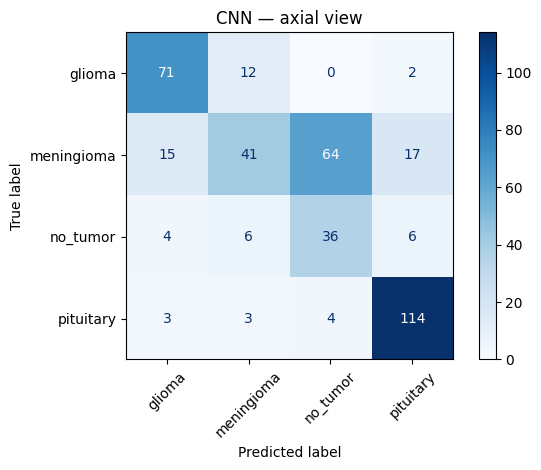


Test accuracy: 0.6583


In [ ]:
#Evaluation on Test Set
y_true = le.transform(test_view_df["class"].values)
y_pred_probs = model.predict(test_ds)
y_pred_cnn = np.argmax(y_pred_probs, axis=1)

print("Classification Report (CNN, axial view):\n")
print(classification_report(y_true, y_pred_cnn, target_names=CLASS_NAMES))

cm = confusion_matrix(y_true, y_pred_cnn)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=CLASS_NAMES)
disp.plot(cmap="Blues", xticks_rotation=45)
plt.title(f"CNN — {VIEW_TO_USE} view")
plt.tight_layout()
plt.show()

test_accuracy = (y_pred_cnn == y_true).mean()
print(f"\nTest accuracy: {test_accuracy:.4f}")

# Examining Misclassified Meningioma Images - Axial View

Misclassified meningioma (predicted no_tumor): 64
Correctly classified meningioma: 41


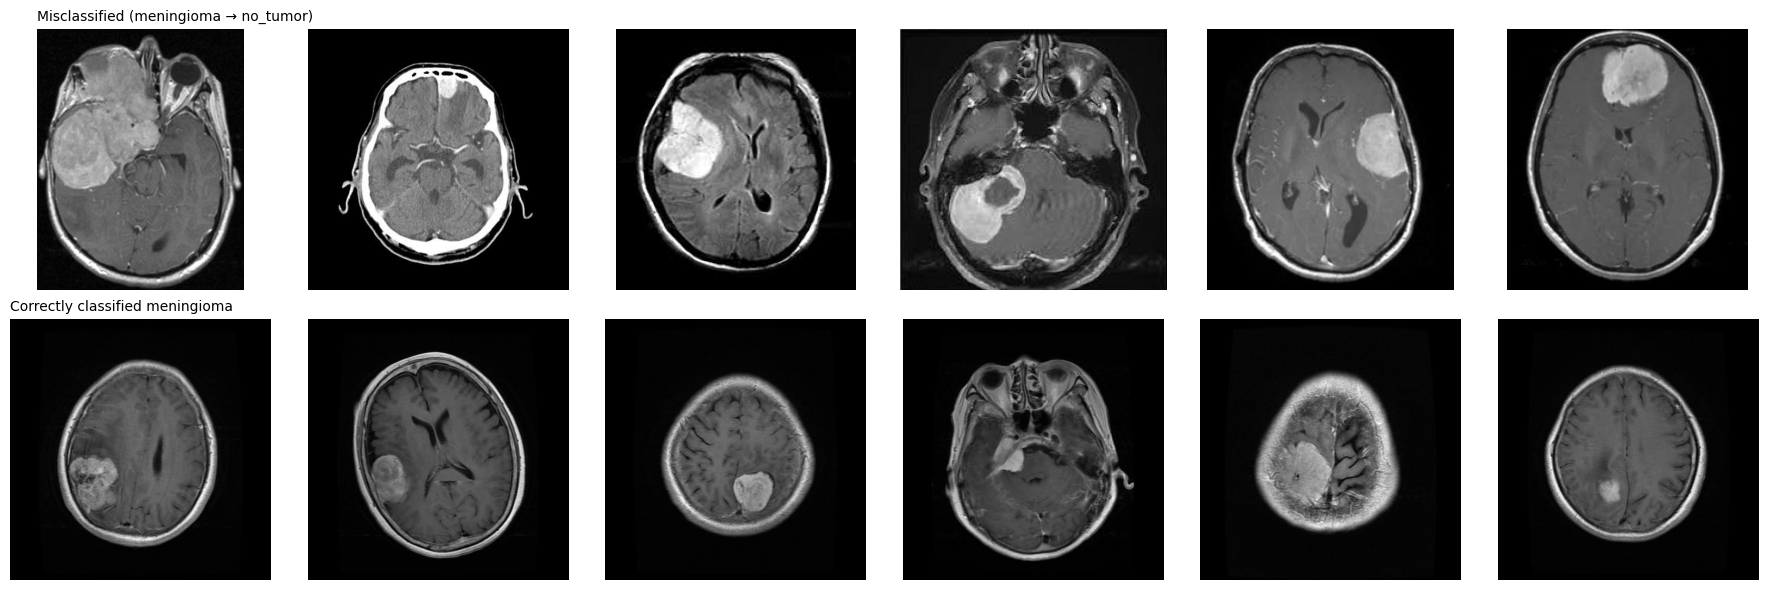


Mean brightness and contrast by group:
              mean_brightness            std_contrast           
                         mean        std         mean        std
group                                                           
correct             32.182457   2.766059    46.819431   3.582470
misclassified       75.875786  17.751011    65.995285  10.492587


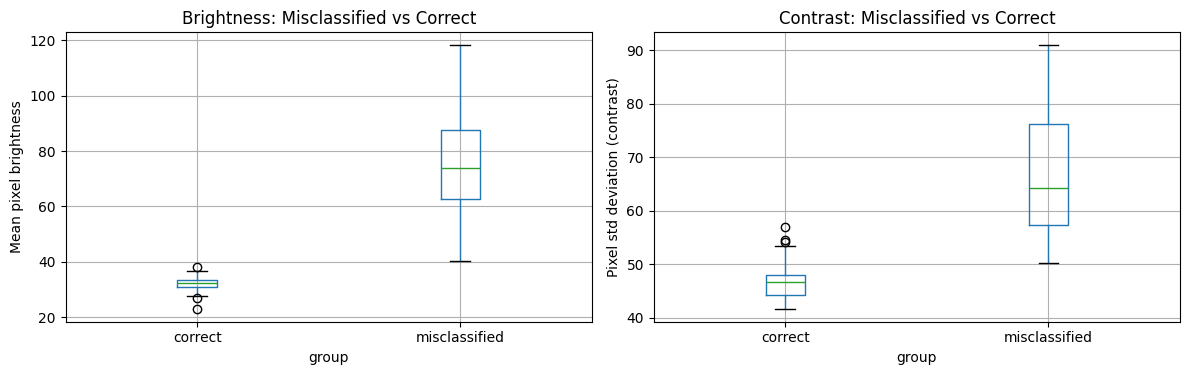


Estimated bright-region fraction by group (rough tumor-size proxy):
                   mean       std
group                            
correct        0.844231  0.094729
misclassified  0.633635  0.239543


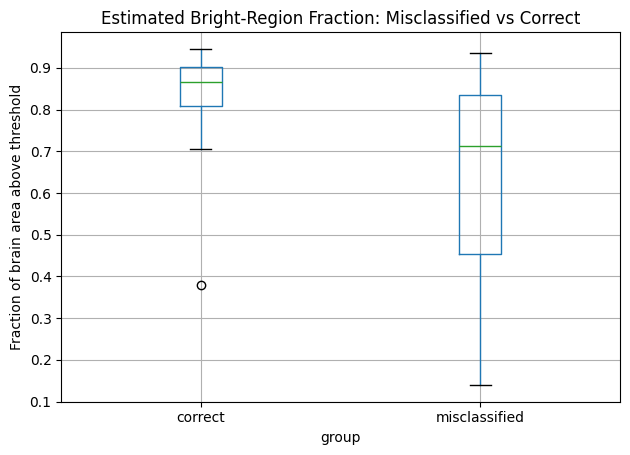

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
import cv2

#Identify misclassified meningioma cases
# adjust class indices to match your CLASS_NAMES order: ['glioma' 'meningioma' 'no_tumor' 'pituitary']
meningioma_class_idx = list(CLASS_NAMES).index("meningioma")
no_tumor_class_idx = list(CLASS_NAMES).index("no_tumor")

# meningioma images misclassified as no_tumor (the dominant error)
misclassified_idx = np.where((y_true == meningioma_class_idx) & (y_pred_cnn == no_tumor_class_idx))[0]
# meningioma images correctly classified, for comparison
correct_idx = np.where((y_true == meningioma_class_idx) & (y_pred_cnn == meningioma_class_idx))[0]

print(f"Misclassified meningioma (predicted no_tumor): {len(misclassified_idx)}")
print(f"Correctly classified meningioma: {len(correct_idx)}")

misclassified_paths = test_view_df.iloc[misclassified_idx]["path"].values
correct_paths = test_view_df.iloc[correct_idx]["path"].values

#Visual side-by-side: misclassified vs correct
n_show = 6
fig, axes = plt.subplots(2, n_show, figsize=(18, 6))

for i in range(min(n_show, len(misclassified_paths))):
    img = Image.open(misclassified_paths[i]).convert("L")
    axes[0, i].imshow(img, cmap="gray")
    axes[0, i].axis("off")
    if i == 0:
        axes[0, i].set_ylabel("Misclassified", fontsize=12)
axes[0, 0].set_title("Misclassified (meningioma → no_tumor)", loc="left", fontsize=10)

for i in range(min(n_show, len(correct_paths))):
    img = Image.open(correct_paths[i]).convert("L")
    axes[1, i].imshow(img, cmap="gray")
    axes[1, i].axis("off")
axes[1, 0].set_title("Correctly classified meningioma", loc="left", fontsize=10)

plt.tight_layout()
plt.show()

#Quantify contrast and brightness for both groups
def compute_image_stats(paths):
    stats = []
    for p in paths:
        img = np.array(Image.open(p).convert("L"), dtype=np.float32)
        stats.append({
            "path": p,
            "mean_brightness": img.mean(),
            "std_contrast": img.std(),
            "max_val": img.max(),
            "min_val": img.min()
        })
    return pd.DataFrame(stats)

misclassified_stats = compute_image_stats(misclassified_paths)
correct_stats = compute_image_stats(correct_paths)

misclassified_stats["group"] = "misclassified"
correct_stats["group"] = "correct"
combined_stats = pd.concat([misclassified_stats, correct_stats])

print("\nMean brightness and contrast by group:")
print(combined_stats.groupby("group")[["mean_brightness", "std_contrast"]].agg(["mean", "std"]))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
combined_stats.boxplot(column="mean_brightness", by="group", ax=axes[0])
axes[0].set_title("Brightness: Misclassified vs Correct")
axes[0].set_ylabel("Mean pixel brightness")

combined_stats.boxplot(column="std_contrast", by="group", ax=axes[1])
axes[1].set_title("Contrast: Misclassified vs Correct")
axes[1].set_ylabel("Pixel std deviation (contrast)")

plt.suptitle("")
plt.tight_layout()
plt.show()

#Rough tumor-region size estimate via simple thresholding
# This is a crude proxy, not a real segmentation — Otsu threshold to isolate bright regions,
# then measure how much of the brain area is "unusually bright" relative to background.
def estimate_bright_region_fraction(path):
    img = np.array(Image.open(path).convert("L"))
    _, thresh = cv2.threshold(img, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    brain_mask = img > 10  # exclude pure black background
    if brain_mask.sum() == 0:
        return 0.0
    bright_fraction = (thresh > 0).sum() / brain_mask.sum()
    return bright_fraction

combined_stats["bright_region_fraction"] = combined_stats["path"].apply(estimate_bright_region_fraction)

print("\nEstimated bright-region fraction by group (rough tumor-size proxy):")
print(combined_stats.groupby("group")["bright_region_fraction"].agg(["mean", "std"]))

combined_stats.boxplot(column="bright_region_fraction", by="group")
plt.title("Estimated Bright-Region Fraction: Misclassified vs Correct")
plt.ylabel("Fraction of brain area above threshold")
plt.suptitle("")
plt.tight_layout()
plt.show()

This suggests that suggests the misclassified meningioma images are systematically brighter and more variable than the ones the model gets right. One possible explanation is that the correctly classified group may represent a specific, consistent presentation of meningioma that the model learned well, while the misclassified group is a more heterogeneous mix of images including different contrast settings, different scan intensity, and possibly different real-world imaging conditions that the model hasn't seen enough consistent examples of to generalize to. For the bright-region fraction, the correctly classified group is tightly clustered high, mostly between 0.8 and 0.95 meaning a large portion of the brain area is "bright" by this rough threshold. The misclassified group has a much wider spread, from as low as approximately 0.14 up to 0.93, with a lower median ( approximately 0.7) and a much bigger interquartile range. It suggests some misclassified meningioma cases have a much smaller bright/abnormal region than the typical meningioma case, which makes a smaller, less visually prominent tumor look enough like a normal scan that the model defaults to no tumor.

Misclassified meningioma images with lowest bright-region fraction:
                                                 path  bright_region_fraction  \
14  /content/drive/MyDrive/INFO442/brisc2025/class...                0.139873   
35  /content/drive/MyDrive/INFO442/brisc2025/class...                0.140483   
18  /content/drive/MyDrive/INFO442/brisc2025/class...                0.156865   
51  /content/drive/MyDrive/INFO442/brisc2025/class...                0.166388   
41  /content/drive/MyDrive/INFO442/brisc2025/class...                0.166510   
6   /content/drive/MyDrive/INFO442/brisc2025/class...                0.228447   

    mean_brightness  std_contrast  
14        81.040131     50.870529  
35        80.984093     50.929832  
18       104.109177     60.835064  
51        92.477310     70.056480  
41        93.316917     69.871780  
6        100.945480     76.281311  


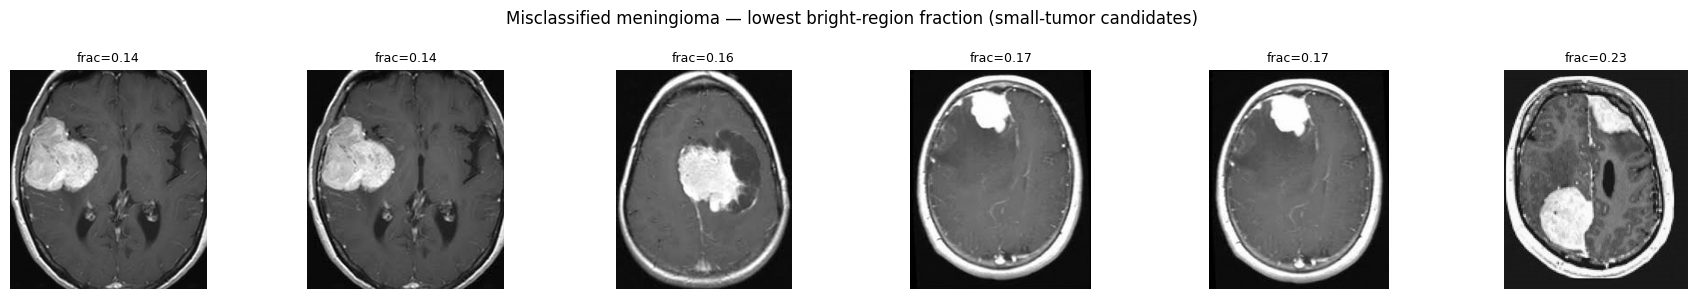

In [ ]:
#Pull out the misclassified images with the lowest bright-region fraction
# (i.e. the ones most consistent with the "small/subtle tumor" hypothesis)
misclassified_only = combined_stats[combined_stats["group"] == "misclassified"].copy()
misclassified_only = misclassified_only.sort_values("bright_region_fraction", ascending=True)

n_lowest = 6
lowest_fraction_rows = misclassified_only.head(n_lowest)

print("Misclassified meningioma images with lowest bright-region fraction:")
print(lowest_fraction_rows[["path", "bright_region_fraction", "mean_brightness", "std_contrast"]])

fig, axes = plt.subplots(1, n_lowest, figsize=(18, 3))
for i, (_, row) in enumerate(lowest_fraction_rows.iterrows()):
    img = Image.open(row["path"]).convert("L")
    axes[i].imshow(img, cmap="gray")
    axes[i].set_title(f"frac={row['bright_region_fraction']:.2f}", fontsize=9)
    axes[i].axis("off")
plt.suptitle("Misclassified meningioma — lowest bright-region fraction (small-tumor candidates)")
plt.tight_layout()
plt.show()

In [ ]:
# compare these specific misclassified images' brightness/contrast against the full correct group
print(lowest_fraction_rows[["path", "mean_brightness", "std_contrast"]])
print("\nCorrect group brightness/contrast range for comparison:")
print(correct_stats[["mean_brightness", "std_contrast"]].describe())

                                                 path  mean_brightness  \
14  /content/drive/MyDrive/INFO442/brisc2025/class...        81.040131   
35  /content/drive/MyDrive/INFO442/brisc2025/class...        80.984093   
18  /content/drive/MyDrive/INFO442/brisc2025/class...       104.109177   
51  /content/drive/MyDrive/INFO442/brisc2025/class...        92.477310   
41  /content/drive/MyDrive/INFO442/brisc2025/class...        93.316917   
6   /content/drive/MyDrive/INFO442/brisc2025/class...       100.945480   

    std_contrast  
14     50.870529  
35     50.929832  
18     60.835064  
51     70.056480  
41     69.871780  
6      76.281311  

Correct group brightness/contrast range for comparison:
       mean_brightness  std_contrast
count        41.000000     41.000000
mean         32.182453     46.819435
std           2.766059      3.582471
min          23.106726     41.673817
25%          31.053684     44.266933
50%          32.495396     46.593849
75%          33.568741     47.98

This shows that the model has learned that meningioma looks like a specific, narrow brightness/contrast profile (dim, moderate contrast), and when a genuine meningioma case falls outside that profile even with an obvious, large, visible tumor the model defaults to no tumor instead.

##Intensity Normalization to improve Meningioma Recall

In [ ]:
from sklearn.utils.class_weight import compute_class_weight

train_labels_enc = le.transform(train_split_df["class"].values)
class_weights_arr = compute_class_weight("balanced", classes=np.unique(train_labels_enc), y=train_labels_enc)
class_weight_dict = dict(enumerate(class_weights_arr))
print("Class weights:", class_weight_dict)

Class weights: {0: np.float64(1.0111940298507462), 1: np.float64(0.9435933147632312), 2: np.float64(1.132943143812709), 3: np.float64(0.9357734806629834)}


Normalized dataset element spec: (TensorSpec(shape=(None, 128, 128, 1), dtype=tf.float32, name=None), TensorSpec(shape=(None,), dtype=tf.int64, name=None))
Epoch 1/30
43/43 ━━━━━━━━━━━━━━━━━━━━ 10s 108ms/step - accuracy: 0.2738 - loss: 1.3840 - val_accuracy: 0.2667 - val_loss: 1.3777 - learning_rate: 5.0000e-05
Epoch 2/30
43/43 ━━━━━━━━━━━━━━━━━━━━ 3s 29ms/step - accuracy: 0.2635 - loss: 1.3813 - val_accuracy: 0.2667 - val_loss: 1.3735 - learning_rate: 5.0000e-05
Epoch 3/30
43/43 ━━━━━━━━━━━━━━━━━━━━ 4s 34ms/step - accuracy: 0.2915 - loss: 1.3773 - val_accuracy: 0.2667 - val_loss: 1.3681 - learning_rate: 5.0000e-05
Epoch 4/30
43/43 ━━━━━━━━━━━━━━━━━━━━ 6s 29ms/step - accuracy: 0.3240 - loss: 1.3702 - val_accuracy: 0.2792 - val_loss: 1.3616 - learning_rate: 5.0000e-05
Epoch 5/30
43/43 ━━━━━━━━━━━━━━━━━━━━ 3s 30ms/step - accuracy: 0.3343 - loss: 1.3667 - val_accuracy: 0.3292 - val_loss: 1.3520 - learning_rate: 5.0000e-05
Epoch 6/30
43/43 ━━━━━━━━━━━━━━━━━━━━ 3s 29ms/step - accuracy: 0.38

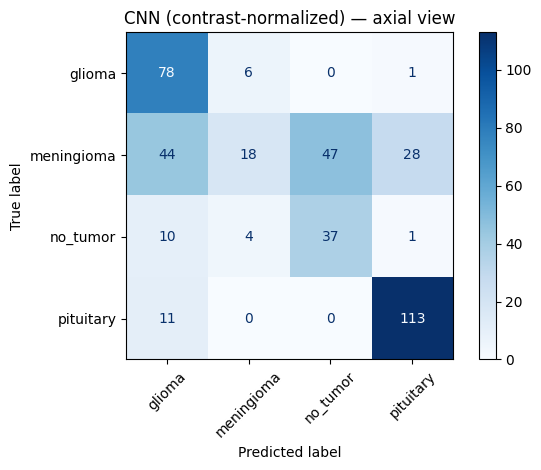


Test accuracy: 0.6181

Meningioma recall — contrast-normalized CNN: 0.131
Overall accuracy — contrast-normalized CNN: 0.6181


In [ ]:
# ---- Imports ----
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers, models
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import collections

#Contrast-normalized data pipeline
def load_and_preprocess_normalized(path, label):
    img = tf.io.read_file(path)
    img = tf.image.decode_jpeg(img, channels=1)
    img = tf.image.resize(img, [IMG_SIZE, IMG_SIZE])
    img = tf.image.per_image_standardization(img)
    return img, label

def make_dataset_normalized(df, shuffle=False):
    paths = df["path"].values
    labels = le.transform(df["class"].values)
    ds = tf.data.Dataset.from_tensor_slices((paths, labels))
    ds = ds.map(load_and_preprocess_normalized, num_parallel_calls=tf.data.AUTOTUNE)
    if shuffle:
        ds = ds.shuffle(buffer_size=len(df))
    ds = ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
    return ds

train_ds_norm = make_dataset_normalized(train_split_df, shuffle=True)
val_ds_norm = make_dataset_normalized(val_split_df, shuffle=False)
test_ds_norm = make_dataset_normalized(test_view_df, shuffle=False)

print("Normalized dataset element spec:", train_ds_norm.element_spec)


#Build and train the CNN on normalized data, lower learning rate
def build_cnn(img_size, num_classes):
    model = models.Sequential([
        layers.Input(shape=(img_size, img_size, 1)),
        layers.Conv2D(32, 3, padding="same", activation="relu"),
        layers.MaxPooling2D(),
        layers.Conv2D(64, 3, padding="same", activation="relu"),
        layers.MaxPooling2D(),
        layers.Conv2D(128, 3, padding="same", activation="relu"),
        layers.MaxPooling2D(),
        layers.GlobalAveragePooling2D(),
        layers.Dense(128, activation="relu"),
        layers.Dropout(0.4),
        layers.Dense(num_classes, activation="softmax"),
    ])
    return model

tf.keras.backend.clear_session()

model_norm = build_cnn(IMG_SIZE, NUM_CLASSES)
model_norm.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=5e-5),  # lowered from 1e-4
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

callbacks = [
    tf.keras.callbacks.EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True),
    tf.keras.callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=3),
]

history_norm = model_norm.fit(
    train_ds_norm, validation_data=val_ds_norm, epochs=30,
    class_weight=class_weight_dict, callbacks=callbacks
)

# per-epoch printout to check for collapse (frozen val_accuracy)
for i, (loss, acc, val_loss, val_acc) in enumerate(zip(
    history_norm.history["loss"], history_norm.history["accuracy"],
    history_norm.history["val_loss"], history_norm.history["val_accuracy"]
)):
    print(f"Epoch {i+1}: loss={loss:.4f}, acc={acc:.4f}, val_loss={val_loss:.4f}, val_acc={val_acc:.4f}")


#Evaluate on the normalized test set
y_pred_probs_norm = model_norm.predict(test_ds_norm)
y_pred_norm = np.argmax(y_pred_probs_norm, axis=1)

print("\nPredicted class distribution:", collections.Counter(y_pred_norm))

print("\nClassification Report (CNN, contrast-normalized, axial view):\n")
print(classification_report(y_true, y_pred_norm, target_names=CLASS_NAMES))

cm = confusion_matrix(y_true, y_pred_norm)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=CLASS_NAMES)
disp.plot(cmap="Blues", xticks_rotation=45)
plt.title(f"CNN (contrast-normalized) — {VIEW_TO_USE} view")
plt.tight_layout()
plt.show()

test_accuracy_norm = (y_pred_norm == y_true).mean()
print(f"\nTest accuracy: {test_accuracy_norm:.4f}")


#Normalized results on their own
report_norm = classification_report(y_true, y_pred_norm, target_names=CLASS_NAMES, output_dict=True)

print(f"\nMeningioma recall — contrast-normalized CNN: {report_norm['meningioma']['recall']:.3f}")
print(f"Overall accuracy — contrast-normalized CNN: {test_accuracy_norm:.4f}")

normalization_results = {
    "cnn_axial_normalized": {
        "accuracy": test_accuracy_norm,
        "report": report_norm
    }
}

##CNN v2 setup

In [ ]:
#CNN v2 - setup
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

EPOCHS_V2 = 300
LR_V2 = 3e-4
ES_PATIENCE = 20
LR_PATIENCE = 7

_required = ["le", "CLASS_NAMES", "IMG_SIZE", "BATCH_SIZE", "NUM_CLASSES",
             "build_cnn", "make_dataset", "train_df", "test_df"]
_missing = [n for n in _required if n not in globals()]
if _missing:
    raise NameError(f"Not in the session: {_missing}. Run the axial cells above first.")

if "BUILD_DS" not in globals():
    BUILD_DS = make_dataset

for _n in ["cnn_v2_results", "cnn_v2_models", "cnn_v2_histories"]:
    if _n not in globals():
        globals()[_n] = {}


def train_cnn_v2(view, epochs=EPOCHS_V2, learning_rate=LR_V2, use_class_weights=True):
    print(f"\n{'='*62}\nCNN v2 - {view}\n{'='*62}")

    # same 85/15 stratified split, same random_state, so this is directly comparable
    train_view = train_df[train_df["view"] == view].reset_index(drop=True)
    test_view = test_df[test_df["view"] == view].reset_index(drop=True)
    tr, va = train_test_split(train_view, test_size=0.15,
                              stratify=train_view["class"], random_state=42)
    print(f"train {len(tr)} | val {len(va)} | test {len(test_view)}")

    train_ds_v = BUILD_DS(tr, shuffle=True, augment=True)
    val_ds_v = BUILD_DS(va, shuffle=False, augment=False)
    test_ds_v = BUILD_DS(test_view, shuffle=False, augment=False)

    class_weights = None
    if use_class_weights:
        # The CNN cells never passed class_weight, only the transfer learning ones did.
        # Keyed off the actual encoded labels, since enumerate() mis-keys if a class is absent.
        enc = le.transform(tr["class"].values)
        present = np.unique(enc)
        w = compute_class_weight("balanced", classes=present, y=enc)
        class_weights = dict(zip(present.tolist(), w.tolist()))
        print("class weights:", {CLASS_NAMES[k]: round(v, 3) for k, v in class_weights.items()})

    model_v = build_cnn(IMG_SIZE, NUM_CLASSES)
    model_v.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=learning_rate),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"],
    )

    callbacks = [
        tf.keras.callbacks.EarlyStopping(monitor="val_loss", patience=ES_PATIENCE,
                                         restore_best_weights=True, verbose=1),
        tf.keras.callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.5,
                                             patience=LR_PATIENCE, min_lr=1e-6, verbose=1),
    ]

    # verbose=2 prints one compact line per epoch, which beats 300 progress bars
    history = model_v.fit(train_ds_v, validation_data=val_ds_v, epochs=epochs,
                          class_weight=class_weights, callbacks=callbacks, verbose=2)

    h = history.history
    ran = len(h["loss"])
    best_epoch = int(np.argmin(h["val_loss"])) + 1
    print(f"\nran {ran} of {epochs} epochs | best val_loss at epoch {best_epoch} "
          f"({min(h['val_loss']):.4f})")
    if ran >= epochs:
        print(">> HIT THE EPOCH CAP. This is exactly what happened at 30 epochs before.")
        print(">> val_loss was still improving. Raise EPOCHS_V2 and run this view again.")
    else:
        print(">> EarlyStopping fired, so the model actually converged this time.")

    #Training curves
    fig_v, axes_v = plt.subplots(1, 2, figsize=(12, 4))
    axes_v[0].plot(h["accuracy"], label="train")
    axes_v[0].plot(h["val_accuracy"], label="val")
    axes_v[0].set_title(f"Accuracy ({view}, v2)")
    axes_v[0].legend()
    axes_v[1].plot(h["loss"], label="train")
    axes_v[1].plot(h["val_loss"], label="val")
    axes_v[1].axvline(best_epoch - 1, ls="--", c="grey", lw=1)
    axes_v[1].set_title(f"Loss ({view}, v2)")
    axes_v[1].legend()
    plt.tight_layout()
    plt.show()

    #Evaluation
    y_true_v = le.transform(test_view["class"].values)
    y_pred_v = np.argmax(model_v.predict(test_ds_v), axis=1)

    print(f"\nClassification Report (CNN v2, {view} view):\n")
    print(classification_report(y_true_v, y_pred_v, target_names=CLASS_NAMES, zero_division=0))

    cm_v = confusion_matrix(y_true_v, y_pred_v)
    ConfusionMatrixDisplay(confusion_matrix=cm_v, display_labels=CLASS_NAMES).plot(
        cmap="Blues", xticks_rotation=45)
    plt.title(f"CNN v2 - {view} view")
    plt.tight_layout()
    plt.show()

    acc = float((y_pred_v == y_true_v).mean())
    report = classification_report(y_true_v, y_pred_v, target_names=CLASS_NAMES,
                                   output_dict=True, zero_division=0)
    print(f"\nTest accuracy: {acc:.4f}")

    cnn_v2_results[view] = {
        "accuracy": acc, "report": report,
        "y_true": y_true_v, "y_pred": y_pred_v,
        "test_df": test_view, "epochs_run": ran, "best_epoch": best_epoch,
    }
    cnn_v2_models[view] = model_v
    cnn_v2_histories[view] = history
    return model_v


##CNN v2 - Axial


CNN v2 - axial
train 1355 | val 240 | test 398
class weights: {'glioma': 1.011, 'meningioma': 0.944, 'no_tumor': 1.133, 'pituitary': 0.936}
Epoch 1/300
43/43 - 13s - 307ms/step - accuracy: 0.2310 - loss: 1.3800 - val_accuracy: 0.2208 - val_loss: 1.3724 - learning_rate: 3.0000e-04
Epoch 2/300
43/43 - 8s - 187ms/step - accuracy: 0.2494 - loss: 1.3567 - val_accuracy: 0.2333 - val_loss: 1.3352 - learning_rate: 3.0000e-04
Epoch 3/300
43/43 - 6s - 136ms/step - accuracy: 0.4214 - loss: 1.2522 - val_accuracy: 0.4625 - val_loss: 1.1877 - learning_rate: 3.0000e-04
Epoch 4/300
43/43 - 8s - 184ms/step - accuracy: 0.5424 - loss: 1.0779 - val_accuracy: 0.6583 - val_loss: 0.9957 - learning_rate: 3.0000e-04
Epoch 5/300
43/43 - 8s - 186ms/step - accuracy: 0.5705 - loss: 1.0058 - val_accuracy: 0.7042 - val_loss: 0.9474 - learning_rate: 3.0000e-04
Epoch 6/300
43/43 - 8s - 186ms/step - accuracy: 0.6081 - loss: 0.9524 - val_accuracy: 0.7042 - val_loss: 0.8950 - learning_rate: 3.0000e-04
Epoch 7/300
43/43 

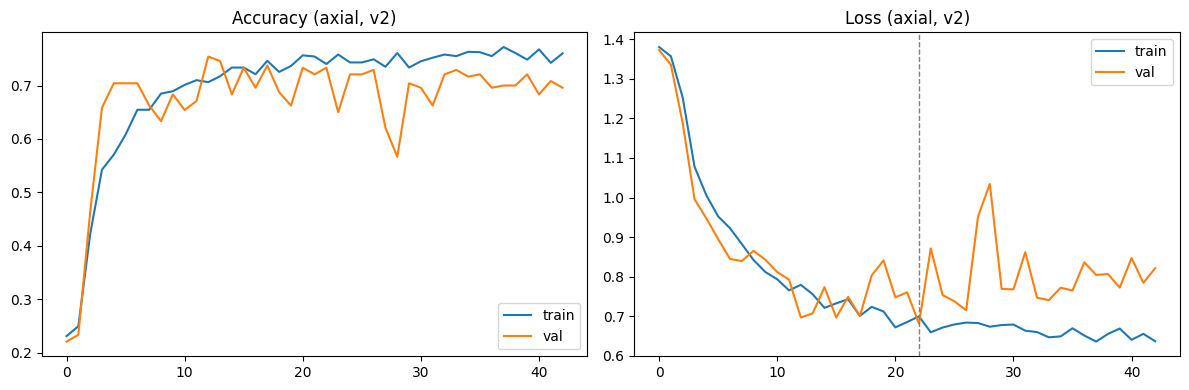

13/13 ━━━━━━━━━━━━━━━━━━━━ 2s 105ms/step

Classification Report (CNN v2, axial view):

              precision    recall  f1-score   support

      glioma       0.78      0.73      0.76        85
  meningioma       0.64      0.41      0.50       137
    no_tumor       0.35      0.75      0.48        52
   pituitary       0.82      0.81      0.81       124

    accuracy                           0.65       398
   macro avg       0.65      0.67      0.64       398
weighted avg       0.69      0.65      0.65       398



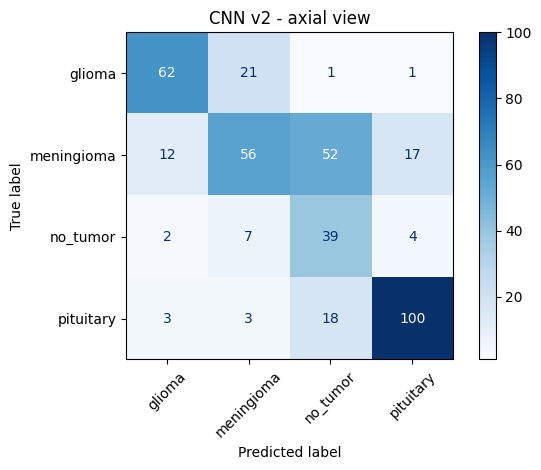


Test accuracy: 0.6457


<Sequential name=sequential_1, built=True>

In [ ]:
#CNN v2 - Axial
train_cnn_v2("axial")

##CNN v2 - Coronal


CNN v2 - coronal
train 1424 | val 252 | test 305
class weights: {'glioma': 0.975, 'meningioma': 0.983, 'no_tumor': 1.348, 'pituitary': 0.822}
Epoch 1/300
45/45 - 13s - 297ms/step - accuracy: 0.2732 - loss: 1.3785 - val_accuracy: 0.3413 - val_loss: 1.3672 - learning_rate: 3.0000e-04
Epoch 2/300
45/45 - 8s - 185ms/step - accuracy: 0.3139 - loss: 1.3275 - val_accuracy: 0.4524 - val_loss: 1.1969 - learning_rate: 3.0000e-04
Epoch 3/300
45/45 - 6s - 132ms/step - accuracy: 0.5197 - loss: 1.1499 - val_accuracy: 0.6230 - val_loss: 0.9713 - learning_rate: 3.0000e-04
Epoch 4/300
45/45 - 8s - 186ms/step - accuracy: 0.5660 - loss: 1.0887 - val_accuracy: 0.6429 - val_loss: 0.9200 - learning_rate: 3.0000e-04
Epoch 5/300
45/45 - 6s - 130ms/step - accuracy: 0.5822 - loss: 1.0411 - val_accuracy: 0.5516 - val_loss: 0.9667 - learning_rate: 3.0000e-04
Epoch 6/300
45/45 - 8s - 182ms/step - accuracy: 0.6004 - loss: 1.0163 - val_accuracy: 0.6905 - val_loss: 0.8623 - learning_rate: 3.0000e-04
Epoch 7/300
45/4

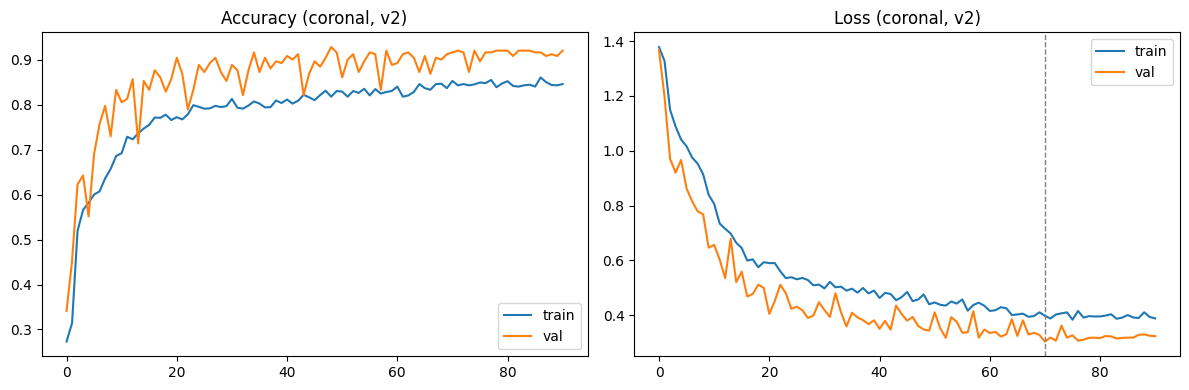

10/10 ━━━━━━━━━━━━━━━━━━━━ 2s 112ms/step

Classification Report (CNN v2, coronal view):

              precision    recall  f1-score   support

      glioma       0.93      0.65      0.77        81
  meningioma       0.66      0.66      0.66        86
    no_tumor       0.74      1.00      0.85        48
   pituitary       0.90      0.97      0.93        90

    accuracy                           0.80       305
   macro avg       0.81      0.82      0.80       305
weighted avg       0.81      0.80      0.80       305



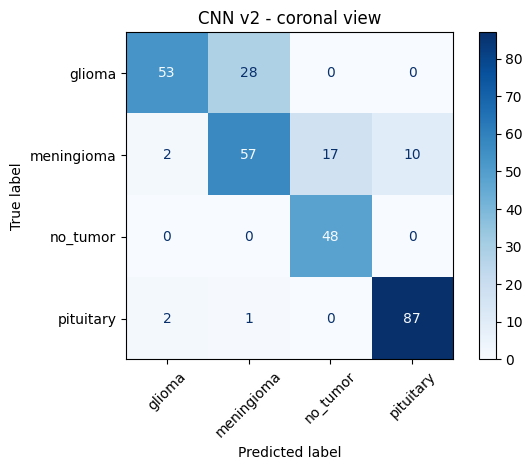


Test accuracy: 0.8033


<Sequential name=sequential_2, built=True>

In [ ]:
#CNN v2 - Coronal
train_cnn_v2("coronal")

##CNN v2 - Sagittal


CNN v2 - sagittal
train 1469 | val 260 | test 297
class weights: {'glioma': 1.34, 'meningioma': 0.9, 'no_tumor': 1.068, 'pituitary': 0.829}
Epoch 1/300
46/46 - 681s - 15s/step - accuracy: 0.2839 - loss: 1.3854 - val_accuracy: 0.3577 - val_loss: 1.3731 - learning_rate: 3.0000e-04
Epoch 2/300
46/46 - 6s - 123ms/step - accuracy: 0.4023 - loss: 1.3529 - val_accuracy: 0.5692 - val_loss: 1.2786 - learning_rate: 3.0000e-04
Epoch 3/300
46/46 - 6s - 138ms/step - accuracy: 0.4847 - loss: 1.2139 - val_accuracy: 0.4846 - val_loss: 1.0917 - learning_rate: 3.0000e-04
Epoch 4/300
46/46 - 6s - 141ms/step - accuracy: 0.5296 - loss: 1.1245 - val_accuracy: 0.6077 - val_loss: 1.0368 - learning_rate: 3.0000e-04
Epoch 5/300
46/46 - 6s - 140ms/step - accuracy: 0.5507 - loss: 1.0919 - val_accuracy: 0.5192 - val_loss: 0.9991 - learning_rate: 3.0000e-04
Epoch 6/300
46/46 - 7s - 142ms/step - accuracy: 0.5909 - loss: 1.0662 - val_accuracy: 0.6846 - val_loss: 0.9772 - learning_rate: 3.0000e-04
Epoch 7/300
46/46 -

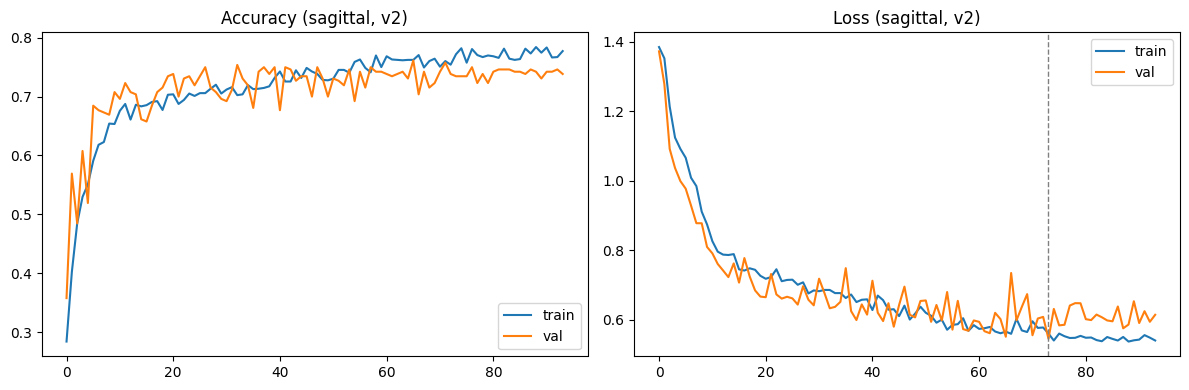

10/10 ━━━━━━━━━━━━━━━━━━━━ 126s 12s/step

Classification Report (CNN v2, sagittal view):

              precision    recall  f1-score   support

      glioma       0.63      0.62      0.63        88
  meningioma       0.62      0.39      0.47        83
    no_tumor       0.75      1.00      0.86        40
   pituitary       0.80      0.98      0.88        86

    accuracy                           0.71       297
   macro avg       0.70      0.75      0.71       297
weighted avg       0.69      0.71      0.69       297



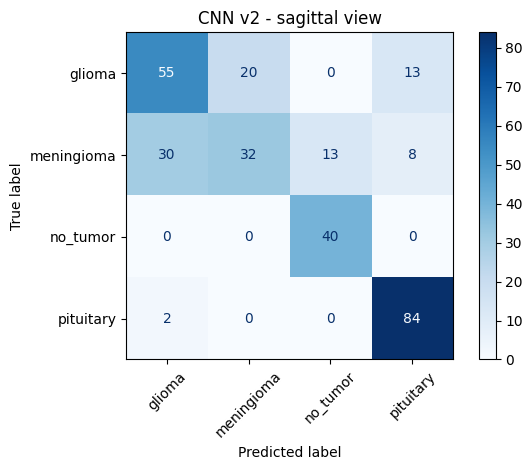


Test accuracy: 0.7104


<Sequential name=sequential_4, built=True>

In [ ]:
#CNN v2 - Sagittal
train_cnn_v2("sagittal")

##CNN v2 - Comparison

In [ ]:
rows = []
for view, res in cnn_v2_results.items():
    row = {"view": view,
           "acc_v2": round(res["accuracy"], 4),
           "epochs_run": res["epochs_run"],
           "best_epoch": res["best_epoch"]}
    for cls in CLASS_NAMES:
        row[f"{cls}_recall_v2"] = round(res["report"][cls]["recall"], 3)
    rows.append(row)

summary = pd.DataFrame(rows).set_index("view")
print("Accuracy and training length:\n")
print(summary[["acc_v2", "epochs_run", "best_epoch"]])

print("\nRecall per class, before and after:\n")
for cls in CLASS_NAMES:
    print(f"  {cls}")
    print(summary[[f"{cls}_recall_v2"]].to_string())

print("\nMacro F1 by view:")
for view, res in cnn_v2_results.items():
    print(f"  {view:9s} {res['report']['macro avg']['f1-score']:.4f}")

#If any view still shows epochs_run == EPOCHS_V2, it is still not done. Raise the cap.
still_capped = [v for v, r in cnn_v2_results.items() if r["epochs_run"] >= EPOCHS_V2]
if still_capped:
    print(f"\nStill hitting the cap: {still_capped}. Raise EPOCHS_V2 and rerun those views.")

Accuracy and training length:

          acc_v2  epochs_run  best_epoch
view                                    
axial     0.7362          55          35
coronal   0.7934          93          73
sagittal  0.7104          94          74

Recall per class, before and after:

  glioma
          glioma_recall_v2
view                      
axial                0.906
coronal              0.691
sagittal             0.625
  meningioma
          meningioma_recall_v2
view                          
axial                    0.431
coronal                  0.593
sagittal                 0.386
  no_tumor
          no_tumor_recall_v2
view                        
axial                  0.769
coronal                1.000
sagittal               1.000
  pituitary
          pituitary_recall_v2
view                         
axial                   0.944
coronal                 0.967
sagittal                0.977

Macro F1 by view:
  axial     0.7153
  coronal   0.7919
  sagittal  0.7106


##Transfer Learning- Setup for Axial View




resnet50
Stage 1: training top layers (base frozen)
Epoch 1/10
43/43 ━━━━━━━━━━━━━━━━━━━━ 29s 305ms/step - accuracy: 0.3867 - loss: 1.7584 - val_accuracy: 0.6583 - val_loss: 0.9295 - learning_rate: 1.0000e-04
Epoch 2/10
43/43 ━━━━━━━━━━━━━━━━━━━━ 6s 55ms/step - accuracy: 0.5771 - loss: 1.1208 - val_accuracy: 0.7042 - val_loss: 0.6788 - learning_rate: 1.0000e-04
Epoch 3/10
43/43 ━━━━━━━━━━━━━━━━━━━━ 8s 53ms/step - accuracy: 0.6317 - loss: 0.9360 - val_accuracy: 0.7125 - val_loss: 0.6465 - learning_rate: 1.0000e-04
Epoch 4/10
43/43 ━━━━━━━━━━━━━━━━━━━━ 6s 56ms/step - accuracy: 0.7048 - loss: 0.7888 - val_accuracy: 0.7667 - val_loss: 0.5653 - learning_rate: 1.0000e-04
Epoch 5/10
43/43 ━━━━━━━━━━━━━━━━━━━━ 8s 48ms/step - accuracy: 0.6996 - loss: 0.7376 - val_accuracy: 0.7917 - val_loss: 0.5336 - learning_rate: 1.0000e-04
Epoch 6/10
43/43 ━━━━━━━━━━━━━━━━━━━━ 6s 52ms/step - accuracy: 0.7491 - loss: 0.6556 - val_accuracy: 0.8333 - val_loss: 0.4847 - learning_rate: 1.0000e-04
Epoch 7/10
43/4

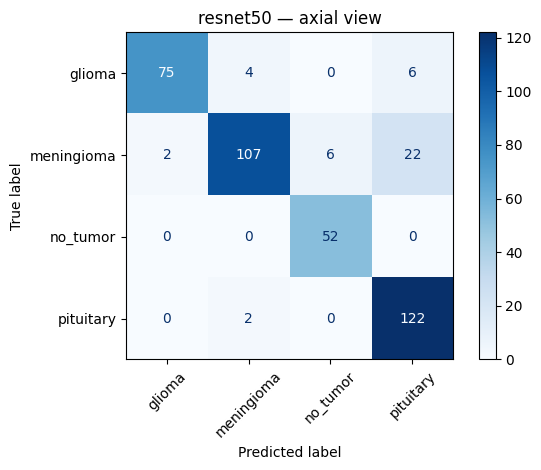


Test accuracy: 0.8945

efficientnetb0
16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
Stage 1: training top layers (base frozen)
Epoch 1/10
43/43 ━━━━━━━━━━━━━━━━━━━━ 69s 852ms/step - accuracy: 0.3993 - loss: 1.3182 - val_accuracy: 0.6750 - val_loss: 1.0229 - learning_rate: 1.0000e-04
Epoch 2/10
43/43 ━━━━━━━━━━━━━━━━━━━━ 7s 52ms/step - accuracy: 0.5882 - loss: 1.0077 - val_accuracy: 0.7167 - val_loss: 0.8262 - learning_rate: 1.0000e-04
Epoch 3/10
43/43 ━━━━━━━━━━━━━━━━━━━━ 6s 33ms/step - accuracy: 0.6502 - loss: 0.8688 - val_accuracy: 0.7208 - val_loss: 0.7392 - learning_rate: 1.0000e-04
Epoch 4/10
43/43 ━━━━━━━━━━━━━━━━━━━━ 6s 50ms/step - accuracy: 0.7203 - loss: 0.7717 - val_accuracy: 0.7375 - val_loss: 0.6811 - learning_rate: 1.0000e-04
Epoch 5/10
43/43 ━━━━━━━━━━━━━━━━━━━━ 6s 30ms/step - accuracy: 0.7373 - loss: 0.6968 - val_accuracy: 0.7500 - val_loss: 0.6451 - learning_rate: 1.0000e-04
Epoch 6/10
43/43 ━━━━━━━━━━━━━━━━━━━━ 5s 29ms/step - accuracy: 0.7550 - loss: 0.6482 - val

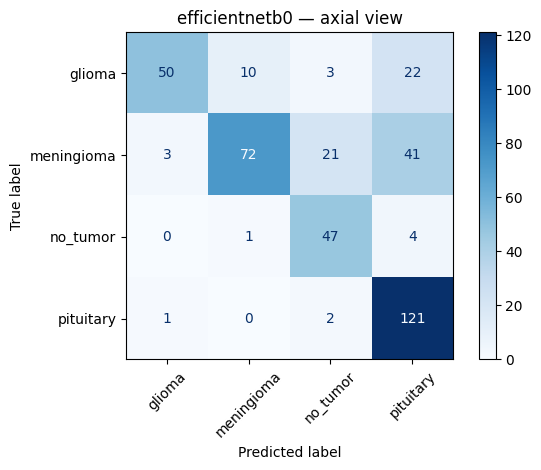


Test accuracy: 0.7286

mobilenetv2
9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
Stage 1: training top layers (base frozen)
Epoch 1/10
43/43 ━━━━━━━━━━━━━━━━━━━━ 45s 600ms/step - accuracy: 0.3432 - loss: 1.6391 - val_accuracy: 0.6125 - val_loss: 0.9391 - learning_rate: 1.0000e-04
Epoch 2/10
43/43 ━━━━━━━━━━━━━━━━━━━━ 5s 26ms/step - accuracy: 0.5092 - loss: 1.1710 - val_accuracy: 0.7042 - val_loss: 0.7508 - learning_rate: 1.0000e-04
Epoch 3/10
43/43 ━━━━━━━━━━━━━━━━━━━━ 7s 34ms/step - accuracy: 0.6199 - loss: 0.9561 - val_accuracy: 0.7292 - val_loss: 0.6852 - learning_rate: 1.0000e-04
Epoch 4/10
43/43 ━━━━━━━━━━━━━━━━━━━━ 5s 24ms/step - accuracy: 0.6554 - loss: 0.8542 - val_accuracy: 0.7625 - val_loss: 0.6132 - learning_rate: 1.0000e-04
Epoch 5/10
43/43 ━━━━━━━━━━━━━━━━━━━━ 5s 31ms/step - accuracy: 0.6908 - loss: 0.7901 - val_accuracy: 0.7750 - val_loss: 0.5724 - learning_rate: 1.0000e-04
Epoch 6/10
43/43 ━━━━━━━━━━━━━━━━━━━━ 7s 25ms/step - accuracy: 0.7041 - loss: 0.7275 - val_accu

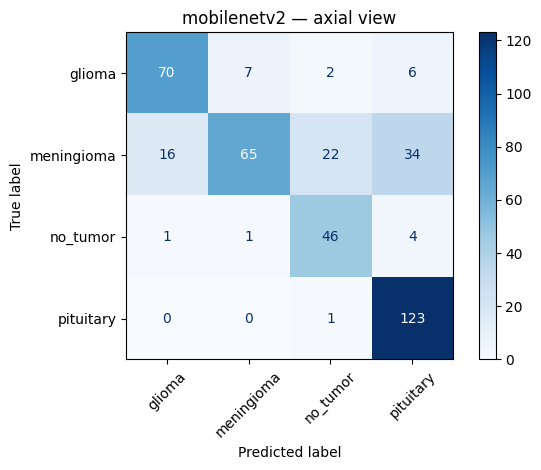


Test accuracy: 0.7638
                accuracy  macro_f1  weighted_f1  meningioma_recall
resnet50        0.894472  0.904473     0.893374           0.781022
mobilenetv2     0.763819  0.756582     0.748027           0.474453
efficientnetb0  0.728643  0.725403     0.718863           0.525547


In [ ]:
#Imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.applications import ResNet50, EfficientNetB0, MobileNetV2
from tensorflow.keras.applications.resnet50 import preprocess_input as resnet_preprocess
from tensorflow.keras.applications.efficientnet import preprocess_input as effnet_preprocess
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input as mobilenet_preprocess
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

# separate dictionary for transfer learning results only
transfer_results = {}


#Model builder
def build_transfer_model(base_class, img_size, num_classes, preprocess_fn):
    base_model = base_class(
        include_top=False,
        weights="imagenet",
        input_shape=(img_size, img_size, 3)
    )
    base_model.trainable = False

    inputs = layers.Input(shape=(img_size, img_size, 1))
    x = layers.Concatenate()([inputs, inputs, inputs])  # grayscale -> 3 channel
    x = layers.Rescaling(255.0)(x)  # undo the 0-1 normalization from load_and_preprocess
    x = preprocess_fn(x)
    x = base_model(x, training=False)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dropout(0.4)(x)
    x = layers.Dense(128, activation="relu")(x)
    x = layers.Dropout(0.3)(x)
    outputs = layers.Dense(num_classes, activation="softmax")(x)

    model = models.Model(inputs, outputs)
    return model, base_model


#Train + evaluate one transfer learning model
def train_and_evaluate_transfer_model(model_name, base_class, preprocess_fn, fine_tune_layers=30):
    print(f"\n{'='*50}\n{model_name}\n{'='*50}")

    tf.keras.backend.clear_session()
    model, base_model = build_transfer_model(base_class, IMG_SIZE, NUM_CLASSES, preprocess_fn)

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

    callbacks = [
        tf.keras.callbacks.EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True),
        tf.keras.callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=3),
    ]

    print("Stage 1: training top layers (base frozen)")
    model.fit(train_ds, validation_data=val_ds, epochs=10,
              class_weight=class_weight_dict, callbacks=callbacks, verbose=1)

    print("Stage 2: fine-tuning top layers of base model")
    base_model.trainable = True
    for layer in base_model.layers[:-fine_tune_layers]:
        layer.trainable = False

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

    history = model.fit(train_ds, validation_data=val_ds, epochs=15,
                         class_weight=class_weight_dict, callbacks=callbacks, verbose=1)

    y_pred_probs = model.predict(test_ds)
    y_pred = np.argmax(y_pred_probs, axis=1)

    print(f"\nClassification Report ({model_name}):\n")
    print(classification_report(y_true, y_pred, target_names=CLASS_NAMES))

    cm = confusion_matrix(y_true, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=CLASS_NAMES)
    disp.plot(cmap="Blues", xticks_rotation=45)
    plt.title(f"{model_name} — {VIEW_TO_USE} view")
    plt.tight_layout()
    plt.show()

    test_accuracy = (y_pred == y_true).mean()
    print(f"\nTest accuracy: {test_accuracy:.4f}")

    transfer_results[model_name] = {
        "accuracy": test_accuracy,
        "report": classification_report(y_true, y_pred, target_names=CLASS_NAMES, output_dict=True)
    }

    return model, history


#Run all three models
resnet_model, resnet_history = train_and_evaluate_transfer_model(
    "resnet50", ResNet50, resnet_preprocess
)

effnet_model, effnet_history = train_and_evaluate_transfer_model(
    "efficientnetb0", EfficientNetB0, effnet_preprocess
)

mobilenet_model, mobilenet_history = train_and_evaluate_transfer_model(
    "mobilenetv2", MobileNetV2, mobilenet_preprocess
)


#Comparison table (transfer learning models only)
transfer_comparison = pd.DataFrame({
    name: {
        "accuracy": res["accuracy"],
        "macro_f1": res["report"]["macro avg"]["f1-score"],
        "weighted_f1": res["report"]["weighted avg"]["f1-score"],
        "meningioma_recall": res["report"]["meningioma"]["recall"],
    }
    for name, res in transfer_results.items()
}).T

print(transfer_comparison.sort_values("accuracy", ascending=False))

##Transfer Learning - Setup for Coronal and Sagittal

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.applications import ResNet50, EfficientNetB0, MobileNetV2
from tensorflow.keras.applications.resnet50 import preprocess_input as resnet_preprocess
from tensorflow.keras.applications.efficientnet import preprocess_input as effnet_preprocess
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input as mobilenet_preprocess
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

_required = ["le", "CLASS_NAMES", "IMG_SIZE", "NUM_CLASSES", "make_dataset",
             "build_transfer_model", "train_df", "test_df"]
_missing = [n for n in _required if n not in globals()]
if _missing:
    raise NameError(
        f"Not in the session: {_missing}. These come from the axial cells above. "
        "If the Colab runtime was restarted you will need to rerun those once."
    )

if "BUILD_DS" not in globals():
    BUILD_DS = make_dataset

if "transfer_results_by_view" not in globals():
    transfer_results_by_view = {}

if "transfer_results" in globals() and transfer_results:
    transfer_results_by_view["axial"] = dict(transfer_results)
    print("Captured the axial transfer results already in memory:", list(transfer_results))

TRANSFER_MODELS = {
    "resnet50":       (ResNet50, resnet_preprocess),
    "efficientnetb0": (EfficientNetB0, effnet_preprocess),
    "mobilenetv2":    (MobileNetV2, mobilenet_preprocess),
}


def prepare_view(view):
    """Datasets, class weights and test labels for one view.

    Same split settings as axial and the same random_state, so this reproduces the
    identical split the CNN cell for that view used.
    """
    train_view = train_df[train_df["view"] == view].reset_index(drop=True)
    test_view = test_df[test_df["view"] == view].reset_index(drop=True)
    tr, va = train_test_split(train_view, test_size=0.15,
                              stratify=train_view["class"], random_state=42)

    # Class weights have to be recomputed per view.
    enc = le.transform(tr["class"].values)
    classes_present = np.unique(enc)
    weights = compute_class_weight("balanced", classes=classes_present, y=enc)
    class_weights = dict(zip(classes_present.tolist(), weights.tolist()))

    return {
        "view": view,
        "train_ds": BUILD_DS(tr, shuffle=True, augment=True),
        "val_ds": BUILD_DS(va, shuffle=False, augment=False),
        "test_ds": BUILD_DS(test_view, shuffle=False, augment=False),
        "y_true": le.transform(test_view["class"].values),
        "class_weights": class_weights,
        "test_df": test_view,
        "n_train": len(tr),
        "n_val": len(va),
    }


def run_transfer_model(model_name, view_data, fine_tune_layers=30, freeze_batchnorm=False):
    """Same two-stage recipe as the axial cell, just parameterized by view."""
    view = view_data["view"]
    base_class, preprocess_fn = TRANSFER_MODELS[model_name]
    print(f"\n{'='*60}\n{model_name} on the {view} view\n{'='*60}")

    tf.keras.backend.clear_session()
    model_v, base_v = build_transfer_model(base_class, IMG_SIZE, NUM_CLASSES, preprocess_fn)

    def fresh_callbacks():
        return [
            tf.keras.callbacks.EarlyStopping(monitor="val_loss", patience=5,
                                             restore_best_weights=True),
            tf.keras.callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=3),
        ]

    model_v.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

    print("Stage 1: training top layers (base frozen)")
    model_v.fit(view_data["train_ds"], validation_data=view_data["val_ds"], epochs=10,
                class_weight=view_data["class_weights"],
                callbacks=fresh_callbacks(), verbose=1)

    print("Stage 2: fine-tuning top layers of base model")
    base_v.trainable = True
    for layer in base_v.layers[:-fine_tune_layers]:
        layer.trainable = False

    if freeze_batchnorm:
        for layer in base_v.layers:
            if isinstance(layer, layers.BatchNormalization):
                layer.trainable = False

    model_v.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

    model_v.fit(view_data["train_ds"], validation_data=view_data["val_ds"], epochs=15,
                class_weight=view_data["class_weights"],
                callbacks=fresh_callbacks(), verbose=1)

    y_true_v = view_data["y_true"]
    y_pred_v = np.argmax(model_v.predict(view_data["test_ds"]), axis=1)

    print(f"\nClassification Report ({model_name}, {view} view):\n")
    print(classification_report(y_true_v, y_pred_v, target_names=CLASS_NAMES))

    cm_v = confusion_matrix(y_true_v, y_pred_v)
    ConfusionMatrixDisplay(confusion_matrix=cm_v, display_labels=CLASS_NAMES).plot(
        cmap="Blues", xticks_rotation=45)
    plt.title(f"{model_name} - {view} view")
    plt.tight_layout()
    plt.show()

    acc = float((y_pred_v == y_true_v).mean())
    print(f"\nTest accuracy: {acc:.4f}")

    transfer_results_by_view.setdefault(view, {})[model_name] = {
        "accuracy": acc,
        "report": classification_report(y_true_v, y_pred_v,
                                        target_names=CLASS_NAMES, output_dict=True),
    }

    del model_v, base_v
    return acc


Captured the axial transfer results already in memory: ['resnet50', 'efficientnetb0', 'mobilenetv2']


##Transfer Learning - Coronal View

coronal: train 1424 | val 252 | test 305
class weights: {'glioma': 0.975, 'meningioma': 0.983, 'no_tumor': 1.348, 'pituitary': 0.822}

resnet50 on the coronal view
Stage 1: training top layers (base frozen)
Epoch 1/10
45/45 ━━━━━━━━━━━━━━━━━━━━ 32s 324ms/step - accuracy: 0.3799 - loss: 1.8358 - val_accuracy: 0.6468 - val_loss: 0.9071 - learning_rate: 1.0000e-04
Epoch 2/10
45/45 ━━━━━━━━━━━━━━━━━━━━ 7s 53ms/step - accuracy: 0.6060 - loss: 0.9949 - val_accuracy: 0.7103 - val_loss: 0.6609 - learning_rate: 1.0000e-04
Epoch 3/10
45/45 ━━━━━━━━━━━━━━━━━━━━ 8s 47ms/step - accuracy: 0.6826 - loss: 0.8101 - val_accuracy: 0.7143 - val_loss: 0.6130 - learning_rate: 1.0000e-04
Epoch 4/10
45/45 ━━━━━━━━━━━━━━━━━━━━ 11s 58ms/step - accuracy: 0.7170 - loss: 0.7083 - val_accuracy: 0.7937 - val_loss: 0.5119 - learning_rate: 1.0000e-04
Epoch 5/10
45/45 ━━━━━━━━━━━━━━━━━━━━ 17s 95ms/step - accuracy: 0.7774 - loss: 0.5818 - val_accuracy: 0.8095 - val_loss: 0.4814 - learning_rate: 1.0000e-04
Epoch 6/10
45/

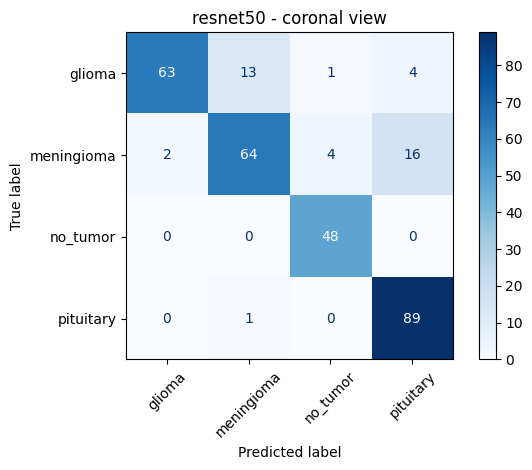


Test accuracy: 0.8656

efficientnetb0 on the coronal view
Stage 1: training top layers (base frozen)
Epoch 1/10
45/45 ━━━━━━━━━━━━━━━━━━━━ 59s 705ms/step - accuracy: 0.3490 - loss: 1.3882 - val_accuracy: 0.6349 - val_loss: 1.0567 - learning_rate: 1.0000e-04
Epoch 2/10
45/45 ━━━━━━━━━━━━━━━━━━━━ 6s 34ms/step - accuracy: 0.5660 - loss: 1.0308 - val_accuracy: 0.7341 - val_loss: 0.8410 - learning_rate: 1.0000e-04
Epoch 3/10
45/45 ━━━━━━━━━━━━━━━━━━━━ 7s 33ms/step - accuracy: 0.6580 - loss: 0.8466 - val_accuracy: 0.7778 - val_loss: 0.7100 - learning_rate: 1.0000e-04
Epoch 4/10
45/45 ━━━━━━━━━━━━━━━━━━━━ 6s 33ms/step - accuracy: 0.6938 - loss: 0.7487 - val_accuracy: 0.7540 - val_loss: 0.6503 - learning_rate: 1.0000e-04
Epoch 5/10
45/45 ━━━━━━━━━━━━━━━━━━━━ 8s 28ms/step - accuracy: 0.7296 - loss: 0.6792 - val_accuracy: 0.7698 - val_loss: 0.5809 - learning_rate: 1.0000e-04
Epoch 6/10
45/45 ━━━━━━━━━━━━━━━━━━━━ 8s 34ms/step - accuracy: 0.7676 - loss: 0.6136 - val_accuracy: 0.7857 - val_loss: 0

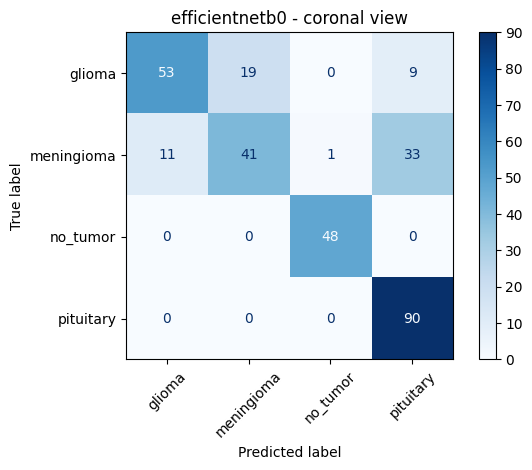


Test accuracy: 0.7607

mobilenetv2 on the coronal view
Stage 1: training top layers (base frozen)
Epoch 1/10
45/45 ━━━━━━━━━━━━━━━━━━━━ 36s 470ms/step - accuracy: 0.3834 - loss: 1.5116 - val_accuracy: 0.6706 - val_loss: 0.8579 - learning_rate: 1.0000e-04
Epoch 2/10
45/45 ━━━━━━━━━━━━━━━━━━━━ 17s 25ms/step - accuracy: 0.6032 - loss: 0.9674 - val_accuracy: 0.7659 - val_loss: 0.6375 - learning_rate: 1.0000e-04
Epoch 3/10
45/45 ━━━━━━━━━━━━━━━━━━━━ 8s 30ms/step - accuracy: 0.6847 - loss: 0.7734 - val_accuracy: 0.7778 - val_loss: 0.5511 - learning_rate: 1.0000e-04
Epoch 4/10
45/45 ━━━━━━━━━━━━━━━━━━━━ 7s 24ms/step - accuracy: 0.7577 - loss: 0.6445 - val_accuracy: 0.8056 - val_loss: 0.4918 - learning_rate: 1.0000e-04
Epoch 5/10
45/45 ━━━━━━━━━━━━━━━━━━━━ 5s 25ms/step - accuracy: 0.7662 - loss: 0.5960 - val_accuracy: 0.8135 - val_loss: 0.4555 - learning_rate: 1.0000e-04
Epoch 6/10
45/45 ━━━━━━━━━━━━━━━━━━━━ 7s 25ms/step - accuracy: 0.7942 - loss: 0.5369 - val_accuracy: 0.8095 - val_loss: 0.4

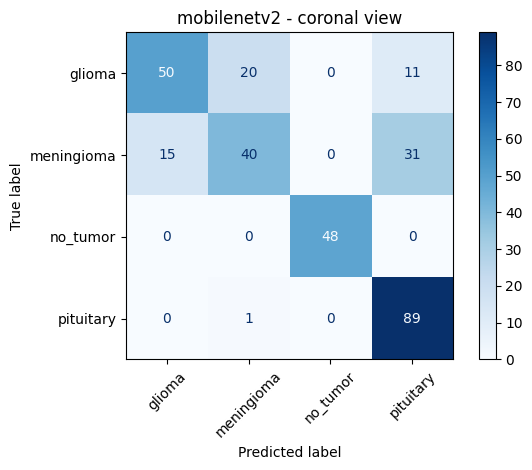


Test accuracy: 0.7443


In [ ]:
#Transfer Learning - Coronal View
coronal_data = prepare_view("coronal")
print(f"coronal: train {coronal_data['n_train']} | val {coronal_data['n_val']} | test {len(coronal_data['y_true'])}")
print("class weights:", {CLASS_NAMES[k]: round(w, 3) for k, w in coronal_data["class_weights"].items()})

for _model_name in TRANSFER_MODELS:
    run_transfer_model(_model_name, coronal_data)


##Transfer Learning - Saggital View

sagittal: train 1469 | val 260 | test 297
class weights: {'glioma': 1.34, 'meningioma': 0.9, 'no_tumor': 1.068, 'pituitary': 0.829}

resnet50 on the sagittal view
Stage 1: training top layers (base frozen)
Epoch 1/10
46/46 ━━━━━━━━━━━━━━━━━━━━ 44s 386ms/step - accuracy: 0.4663 - loss: 1.5603 - val_accuracy: 0.7500 - val_loss: 0.6099 - learning_rate: 1.0000e-04
Epoch 2/10
46/46 ━━━━━━━━━━━━━━━━━━━━ 9s 48ms/step - accuracy: 0.6521 - loss: 0.9065 - val_accuracy: 0.7885 - val_loss: 0.5271 - learning_rate: 1.0000e-04
Epoch 3/10
46/46 ━━━━━━━━━━━━━━━━━━━━ 7s 48ms/step - accuracy: 0.7223 - loss: 0.7392 - val_accuracy: 0.8269 - val_loss: 0.4738 - learning_rate: 1.0000e-04
Epoch 4/10
46/46 ━━━━━━━━━━━━━━━━━━━━ 9s 50ms/step - accuracy: 0.7461 - loss: 0.6640 - val_accuracy: 0.8308 - val_loss: 0.4555 - learning_rate: 1.0000e-04
Epoch 5/10
46/46 ━━━━━━━━━━━━━━━━━━━━ 8s 56ms/step - accuracy: 0.7713 - loss: 0.5805 - val_accuracy: 0.8308 - val_loss: 0.4409 - learning_rate: 1.0000e-04
Epoch 6/10
46/46 

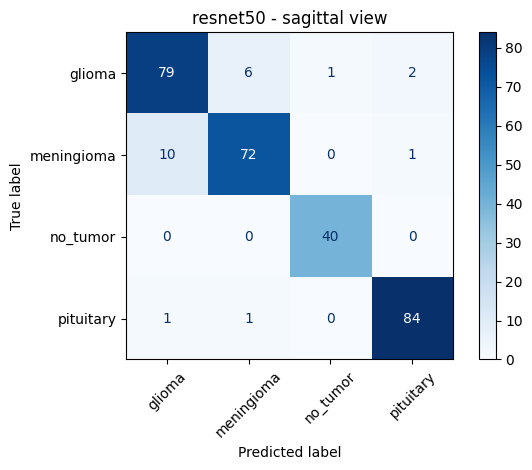


Test accuracy: 0.9259

efficientnetb0 on the sagittal view
Stage 1: training top layers (base frozen)
Epoch 1/10
46/46 ━━━━━━━━━━━━━━━━━━━━ 62s 801ms/step - accuracy: 0.4050 - loss: 1.3194 - val_accuracy: 0.6731 - val_loss: 0.9518 - learning_rate: 1.0000e-04
Epoch 2/10
46/46 ━━━━━━━━━━━━━━━━━━━━ 7s 30ms/step - accuracy: 0.6297 - loss: 0.9576 - val_accuracy: 0.7038 - val_loss: 0.7338 - learning_rate: 1.0000e-04
Epoch 3/10
46/46 ━━━━━━━━━━━━━━━━━━━━ 6s 40ms/step - accuracy: 0.6780 - loss: 0.8155 - val_accuracy: 0.7269 - val_loss: 0.6327 - learning_rate: 1.0000e-04
Epoch 4/10
46/46 ━━━━━━━━━━━━━━━━━━━━ 7s 29ms/step - accuracy: 0.7250 - loss: 0.7002 - val_accuracy: 0.7385 - val_loss: 0.5839 - learning_rate: 1.0000e-04
Epoch 5/10
46/46 ━━━━━━━━━━━━━━━━━━━━ 6s 29ms/step - accuracy: 0.7338 - loss: 0.6606 - val_accuracy: 0.7654 - val_loss: 0.5420 - learning_rate: 1.0000e-04
Epoch 6/10
46/46 ━━━━━━━━━━━━━━━━━━━━ 8s 28ms/step - accuracy: 0.7679 - loss: 0.6060 - val_accuracy: 0.7885 - val_loss: 

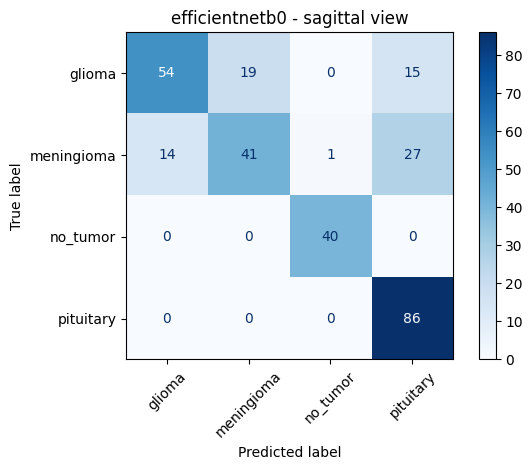


Test accuracy: 0.7441

mobilenetv2 on the sagittal view
Stage 1: training top layers (base frozen)
Epoch 1/10
46/46 ━━━━━━━━━━━━━━━━━━━━ 72s 1s/step - accuracy: 0.3778 - loss: 1.6732 - val_accuracy: 0.6962 - val_loss: 0.8533 - learning_rate: 1.0000e-04
Epoch 2/10
46/46 ━━━━━━━━━━━━━━━━━━━━ 8s 28ms/step - accuracy: 0.5623 - loss: 1.0781 - val_accuracy: 0.7423 - val_loss: 0.6834 - learning_rate: 1.0000e-04
Epoch 3/10
46/46 ━━━━━━━━━━━━━━━━━━━━ 6s 31ms/step - accuracy: 0.6596 - loss: 0.8789 - val_accuracy: 0.7808 - val_loss: 0.5915 - learning_rate: 1.0000e-04
Epoch 4/10
46/46 ━━━━━━━━━━━━━━━━━━━━ 8s 27ms/step - accuracy: 0.6692 - loss: 0.8253 - val_accuracy: 0.8038 - val_loss: 0.5507 - learning_rate: 1.0000e-04
Epoch 5/10
46/46 ━━━━━━━━━━━━━━━━━━━━ 6s 27ms/step - accuracy: 0.7223 - loss: 0.7011 - val_accuracy: 0.8269 - val_loss: 0.5062 - learning_rate: 1.0000e-04
Epoch 6/10
46/46 ━━━━━━━━━━━━━━━━━━━━ 8s 27ms/step - accuracy: 0.7651 - loss: 0.6527 - val_accuracy: 0.8231 - val_loss: 0.4822

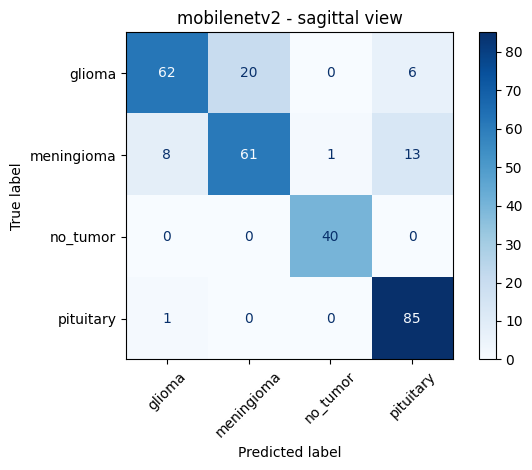


Test accuracy: 0.8350


In [ ]:
#Transfer Learning - Sagittal View
sagittal_data = prepare_view("sagittal")
print(f"sagittal: train {sagittal_data['n_train']} | val {sagittal_data['n_val']} | test {len(sagittal_data['y_true'])}")
print("class weights:", {CLASS_NAMES[k]: round(w, 3) for k, w in sagittal_data["class_weights"].items()})

for _model_name in TRANSFER_MODELS:
    run_transfer_model(_model_name, sagittal_data)


##Transfer Learning- Comparison Across Views

In [ ]:
rows = []
for view, per_model in transfer_results_by_view.items():
    for model_name, res in per_model.items():
        row = {
            "view": view,
            "model": model_name,
            "accuracy": res["accuracy"],
            "macro_f1": res["report"]["macro avg"]["f1-score"],
            "weighted_f1": res["report"]["weighted avg"]["f1-score"],
            "macro_recall": res["report"]["macro avg"]["recall"],
        }
        for cls in CLASS_NAMES:
            row[f"{cls}_recall"] = res["report"][cls]["recall"]
        rows.append(row)

transfer_comparison = (pd.DataFrame(rows)
                       .sort_values(["view", "accuracy"], ascending=[True, False])
                       .reset_index(drop=True))

print("Transfer learning results:\n")
print(transfer_comparison.round(4).to_string(index=False))

print("\nAccuracy (model x view):\n")
print(transfer_comparison.pivot(index="model", columns="view", values="accuracy").round(4))

for cls in CLASS_NAMES:
    print(f"\n{cls} recall (model x view):\n")
    print(transfer_comparison.pivot(index="model", columns="view",
                                    values=f"{cls}_recall").round(4))

Transfer learning results:

    view          model  accuracy  macro_f1  weighted_f1  macro_recall  glioma_recall  meningioma_recall  no_tumor_recall  pituitary_recall
   axial       resnet50    0.8945    0.9045       0.8934        0.9118         0.8824             0.7810           1.0000            0.9839
   axial    mobilenetv2    0.7638    0.7566       0.7480        0.7936         0.8235             0.4745           0.8846            0.9919
   axial efficientnetb0    0.7286    0.7254       0.7189        0.7484         0.5882             0.5255           0.9038            0.9758
 coronal       resnet50    0.8656    0.8721       0.8628        0.8777         0.7778             0.7442           1.0000            0.9889
 coronal efficientnetb0    0.7607    0.7733       0.7475        0.7828         0.6543             0.4767           1.0000            1.0000
 coronal    mobilenetv2    0.7443    0.7586       0.7304        0.7678         0.6173             0.4651           1.0000           

# Segmentation Task

In [ ]:
import os
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from pathlib import Path
from PIL import Image
from sklearn.model_selection import train_test_split
from tensorflow.keras import layers, models

# 1. Paths
try:
    SEG_BASE_DIR = BASE_DIR.parent / "segmentation_task"
except NameError:
    SEG_BASE_DIR = Path("/content/drive/MyDrive/INFO442/brisc2025/segmentation_task")

SEG_TRAIN_IMG_DIR = SEG_BASE_DIR / "train" / "images"
SEG_TRAIN_MASK_DIR = SEG_BASE_DIR / "train" / "masks"
SEG_TEST_IMG_DIR = SEG_BASE_DIR / "test" / "images"
SEG_TEST_MASK_DIR = SEG_BASE_DIR / "test" / "masks"

In [ ]:
# 2. Filename parsing
SEG_FILENAME_PATTERN = re.compile(
    r"brisc2025_(?P<split>train|test)_(?P<id>\d+)_(?P<class_code>gl|me|pi|no)_(?P<view_code>ax|co|sa)_(?P<modality>\w+)",
    re.IGNORECASE
)
CLASS_MAP = {"gl": "glioma", "me": "meningioma", "pi": "pituitary", "no": "no_tumor"}
VIEW_MAP = {"ax": "axial", "co": "coronal", "sa": "sagittal"}

def build_segmentation_index(image_dir, mask_dir, split_name):
    records = []

    image_dir = Path(image_dir)
    mask_dir = Path(mask_dir)

    if not image_dir.exists():
        raise FileNotFoundError(f"Image directory not found: {image_dir}")

    if not mask_dir.exists():
        raise FileNotFoundError(f"Mask directory not found: {mask_dir}")

    for fname in sorted(os.listdir(image_dir)):
        if not fname.lower().endswith((".jpg", ".jpeg")):
            continue

        match = SEG_FILENAME_PATTERN.search(fname)
        if not match:
            print(f"Warning: filename did not match expected pattern: {fname}")
            continue

        image_path = image_dir / fname
        mask_name = Path(fname).with_suffix(".png").name
        mask_path = mask_dir / mask_name

        records.append({
            "path": str(image_path),
            "mask_path": str(mask_path),
            "class": CLASS_MAP[match.group("class_code").lower()],
            "split": split_name,
            "view": VIEW_MAP[match.group("view_code").lower()],
            "modality": match.group("modality").lower(),
            "patient_id": match.group("id"),
            "image_exists": image_path.exists(),
            "mask_exists": mask_path.exists()
        })

    return pd.DataFrame(records)

train_df_seg = build_segmentation_index(SEG_TRAIN_IMG_DIR, SEG_TRAIN_MASK_DIR, "train")
test_df_seg = build_segmentation_index(SEG_TEST_IMG_DIR, SEG_TEST_MASK_DIR, "test")
full_df_seg = pd.concat([train_df_seg, test_df_seg], ignore_index=True)

print("\nSegmentation dataframe sizes:")
print("Train:", train_df_seg.shape)
print("Test:", test_df_seg.shape)
print("Full:", full_df_seg.shape)

print("\nImage/mask existence check:")
print(full_df_seg[["image_exists", "mask_exists"]].value_counts())

display(full_df_seg.head())


Segmentation dataframe sizes:
Train: (3933, 9)
Test: (860, 9)
Full: (4793, 9)

Image/mask existence check:
image_exists  mask_exists
True          True           4793
Name: count, dtype: int64


,path,mask_path,class,split,view,modality,patient_id,image_exists,mask_exists
0,/content/drive/MyDrive/INFO442/brisc2025/segme...,/content/drive/MyDrive/INFO442/brisc2025/segme...,glioma,train,axial,t1,00001,True,True
1,/content/drive/MyDrive/INFO442/brisc2025/segme...,/content/drive/MyDrive/INFO442/brisc2025/segme...,glioma,train,axial,t1,00002,True,True
2,/content/drive/MyDrive/INFO442/brisc2025/segme...,/content/drive/MyDrive/INFO442/brisc2025/segme...,glioma,train,axial,t1,00003,True,True
3,/content/drive/MyDrive/INFO442/brisc2025/segme...,/content/drive/MyDrive/INFO442/brisc2025/segme...,glioma,train,axial,t1,00004,True,True
4,/content/drive/MyDrive/INFO442/brisc2025/segme...,/content/drive/MyDrive/INFO442/brisc2025/segme...,glioma,train,axial,t1,00005,True,True


In [ ]:
# 3. Basic EDA: segmentation counts
print("\nSegmentation class distribution:")
display(pd.crosstab(full_df_seg["class"], full_df_seg["split"]))

print("\nSegmentation view distribution:")
display(pd.crosstab(full_df_seg["view"], full_df_seg["split"]))


Segmentation class distribution:


split,test,train
class,,
glioma,254,1147
meningioma,306,1329
pituitary,300,1457



Segmentation view distribution:


split,test,train
view,,
axial,346,1243
coronal,257,1366
sagittal,257,1324


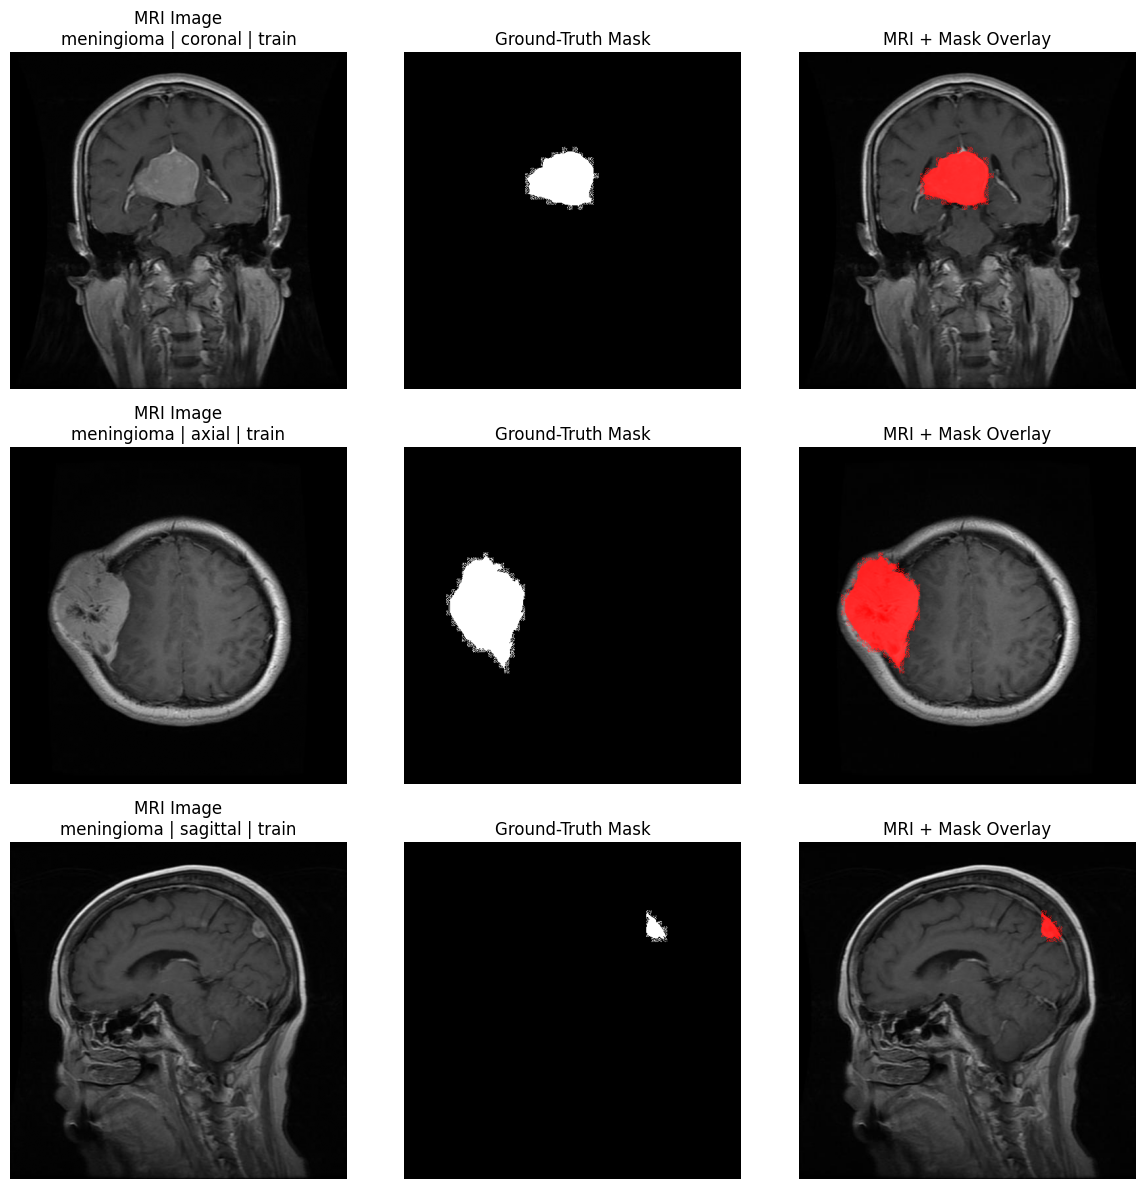

In [ ]:
# 4. Visual sanity check: MRI image, mask, overlay
def show_segmentation_examples(df, n=3, random_state=42):
    valid_df = df[(df["image_exists"]) & (df["mask_exists"])].copy()

    if len(valid_df) == 0:
        raise ValueError("No valid image-mask pairs found. Check SEG_BASE_DIR and folder structure.")

    sample_df = valid_df.sample(min(n, len(valid_df)), random_state=random_state)

    fig, axes = plt.subplots(len(sample_df), 3, figsize=(12, 4 * len(sample_df)))

    if len(sample_df) == 1:
        axes = np.expand_dims(axes, axis=0)

    for row_idx, (_, row) in enumerate(sample_df.iterrows()):
        img = np.array(Image.open(row["path"]).convert("L"))
        mask = np.array(Image.open(row["mask_path"]).convert("L"))

        binary_mask = mask > 0

        overlay = np.stack([img, img, img], axis=-1)
        overlay[binary_mask, 0] = 255
        overlay[binary_mask, 1] = overlay[binary_mask, 1] * 0.4
        overlay[binary_mask, 2] = overlay[binary_mask, 2] * 0.4

        title = f"{row['class']} | {row['view']} | {row['split']}"

        axes[row_idx, 0].imshow(img, cmap="gray")
        axes[row_idx, 0].set_title("MRI Image\n" + title)
        axes[row_idx, 0].axis("off")

        axes[row_idx, 1].imshow(binary_mask, cmap="gray")
        axes[row_idx, 1].set_title("Ground-Truth Mask")
        axes[row_idx, 1].axis("off")

        axes[row_idx, 2].imshow(overlay)
        axes[row_idx, 2].set_title("MRI + Mask Overlay")
        axes[row_idx, 2].axis("off")

    plt.tight_layout()
    plt.show()

show_segmentation_examples(train_df_seg, n=3)


Train mask-fraction summary:


,mask_fraction
count,3933.000000
mean,0.018347
std,0.014769
min,0.000412
25%,0.008595
50%,0.014381
75%,0.023209
max,0.196094



Average mask coverage by class/view:


count      mean    median       min       max
class      view                                                   
meningioma axial       423  0.028578  0.021557  0.002575  0.196094
glioma     sagittal    323  0.021501  0.017071  0.001534  0.091255
meningioma coronal     426  0.020743  0.017187  0.001648  0.100848
           sagittal    480  0.020660  0.017937  0.000412  0.078095
glioma     axial       394  0.020011  0.016598  0.002037  0.092915
           coronal     430  0.019862  0.017963  0.000824  0.078163
pituitary  coronal     510  0.015772  0.014076  0.002510  0.069042
           sagittal    521  0.010484  0.008667  0.001591  0.051365
           axial       426  0.010427  0.009472  0.000938  0.029354

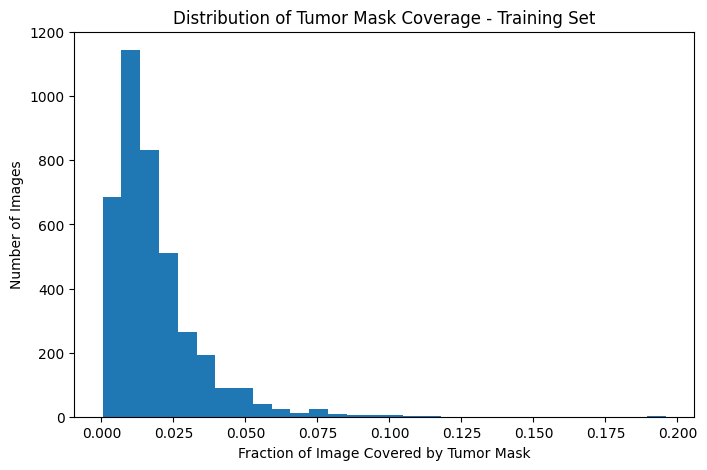

In [ ]:
# 5. Mask-area feature: how much of each image is tumor?
def calculate_mask_fraction(mask_path):
    mask = np.array(Image.open(mask_path).convert("L"))
    binary_mask = mask > 0
    return float(binary_mask.mean())

valid_train_seg = train_df_seg[(train_df_seg["image_exists"]) & (train_df_seg["mask_exists"])].copy()
valid_test_seg = test_df_seg[(test_df_seg["image_exists"]) & (test_df_seg["mask_exists"])].copy()

valid_train_seg["mask_fraction"] = valid_train_seg["mask_path"].apply(calculate_mask_fraction)
valid_test_seg["mask_fraction"] = valid_test_seg["mask_path"].apply(calculate_mask_fraction)

print("\nTrain mask-fraction summary:")
display(valid_train_seg["mask_fraction"].describe())

print("\nAverage mask coverage by class/view:")
display(
    valid_train_seg
    .groupby(["class", "view"])["mask_fraction"]
    .agg(["count", "mean", "median", "min", "max"])
    .sort_values("mean", ascending=False)
)

plt.figure(figsize=(8, 5))
plt.hist(valid_train_seg["mask_fraction"], bins=30)
plt.title("Distribution of Tumor Mask Coverage - Training Set")
plt.xlabel("Fraction of Image Covered by Tumor Mask")
plt.ylabel("Number of Images")
plt.show()


In [ ]:
# 6. tf.data pipeline for segmentation
try:
    SEG_IMG_SIZE = IMG_SIZE
except NameError:
    SEG_IMG_SIZE = 128

SEG_BATCH_SIZE = 16

def load_segmentation_pair(image_path, mask_path):
    # MRI image
    image = tf.io.read_file(image_path)
    image = tf.image.decode_jpeg(image, channels=1)
    image = tf.image.resize(image, [SEG_IMG_SIZE, SEG_IMG_SIZE])
    image = tf.cast(image, tf.float32) / 255.0

    # Binary mask
    mask = tf.io.read_file(mask_path)
    mask = tf.image.decode_png(mask, channels=1)

    mask = tf.image.resize(mask, [SEG_IMG_SIZE, SEG_IMG_SIZE], method="nearest")
    mask = tf.cast(mask > 0, tf.float32)

    return image, mask

def make_segmentation_dataset(df, shuffle=False):
    valid_df = df[(df["image_exists"]) & (df["mask_exists"])].copy()

    ds = tf.data.Dataset.from_tensor_slices(
        (valid_df["path"].values, valid_df["mask_path"].values)
    )

    ds = ds.map(load_segmentation_pair, num_parallel_calls=tf.data.AUTOTUNE)

    if shuffle:
        ds = ds.shuffle(buffer_size=len(valid_df), seed=42)

    ds = ds.batch(SEG_BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
    return ds

# Use validation split from segmentation training data
train_seg_split_df, val_seg_split_df = train_test_split(
    valid_train_seg,
    test_size=0.15,
    stratify=valid_train_seg["class"],
    random_state=42
)

train_seg_ds = make_segmentation_dataset(train_seg_split_df, shuffle=True)
val_seg_ds = make_segmentation_dataset(val_seg_split_df, shuffle=False)
test_seg_ds = make_segmentation_dataset(valid_test_seg, shuffle=False)

for image_batch, mask_batch in train_seg_ds.take(1):
    print("\nSegmentation batch check:")
    print("Image batch:", image_batch.shape)
    print("Mask batch:", mask_batch.shape)
    print("Image range:", float(tf.reduce_min(image_batch)), float(tf.reduce_max(image_batch)))
    print("Mask values:", np.unique(mask_batch.numpy()))


Segmentation batch check:
Image batch: (16, 128, 128, 1)
Mask batch: (16, 128, 128, 1)
Image range: 0.0 0.9607843160629272
Mask values: [0. 1.]


In [ ]:
# Segmentation Model (based on initial classification CNN)
import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt
import numpy as np

tf.keras.backend.clear_session()

## Metrics / loss
def dice_coefficient(y_true, y_pred, smooth=1.0):
    """
    Measures mask overlap.
    - 1.0 = perfect overlap
    - 0.0 = no overlap
    """
    y_true_f = tf.reshape(y_true, [-1])
    y_pred_f = tf.reshape(y_pred, [-1])

    intersection = tf.reduce_sum(y_true_f * y_pred_f)

    return (2.0 * intersection + smooth) / (
        tf.reduce_sum(y_true_f) + tf.reduce_sum(y_pred_f) + smooth
    )

def dice_loss(y_true, y_pred):
    return 1.0 - dice_coefficient(y_true, y_pred)

def combined_bce_dice_loss(y_true, y_pred):
    """
    Binary cross-entropy helps with pixel-level 0/1 prediction.
    Dice loss pushes the model toward better tumor-mask overlap.
    """
    bce = tf.keras.losses.binary_crossentropy(y_true, y_pred)
    return bce + dice_loss(y_true, y_pred)

## CNN segmentation model
def build_classification_cnn_as_segmenter(img_size=128):
    """
    This model keeps the same basic feature-extraction idea as the
    original custom CNN classifier, but instead of ending with:

        GlobalAveragePooling -> Dense -> Softmax class label

    it upsamples back to the original image size and predicts:
        128 x 128 x 1 tumor mask
    """

    inputs = layers.Input(shape=(img_size, img_size, 1))

    x = layers.Conv2D(32, 3, padding="same", activation="relu")(inputs)
    x = layers.MaxPooling2D()(x)   # 128 -> 64

    x = layers.Conv2D(64, 3, padding="same", activation="relu")(x)
    x = layers.MaxPooling2D()(x)   # 64 -> 32

    x = layers.Conv2D(128, 3, padding="same", activation="relu")(x)
    x = layers.MaxPooling2D()(x)   # 32 -> 16

    x = layers.Conv2D(128, 3, padding="same", activation="relu")(x)

    x = layers.UpSampling2D()(x)   # 16 -> 32
    x = layers.Conv2D(128, 3, padding="same", activation="relu")(x)

    x = layers.UpSampling2D()(x)   # 32 -> 64
    x = layers.Conv2D(64, 3, padding="same", activation="relu")(x)

    x = layers.UpSampling2D()(x)   # 64 -> 128
    x = layers.Conv2D(32, 3, padding="same", activation="relu")(x)

    # One output probability per pixel:
    outputs = layers.Conv2D(1, 1, activation="sigmoid", padding="same")(x)

    model = models.Model(inputs=inputs, outputs=outputs)

    return model


seg_cnn_model = build_classification_cnn_as_segmenter(SEG_IMG_SIZE)

seg_cnn_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss=combined_bce_dice_loss,
    metrics=["binary_accuracy", dice_coefficient]
)

seg_cnn_model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 128, 128, 1)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 128, 128, 32)   │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 16, 16, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d (UpSampling2D)    │ (None, 32, 32, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 32, 32, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_1 (UpSampling2D)  │ (None, 64, 64, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 64, 64, 64)     │        73,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_2 (UpSampling2D)  │ (None, 128, 128, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 128, 128, 32)   │        18,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 128, 128, 1)    │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 480,129 (1.83 MB)

 Trainable params: 480,129 (1.83 MB)

 Non-trainable params: 0 (0.00 B)

Image batch shape: (16, 128, 128, 1)
Mask batch shape: (16, 128, 128, 1)
Mask values: [0. 1.]
1/1 ━━━━━━━━━━━━━━━━━━━━ 11s 11s/step - binary_accuracy: 0.6918 - dice_coefficient: 0.0237 - loss: 1.6686
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
Prediction shape: (16, 128, 128, 1)
Prediction range: 0.48951888 to 0.5019205


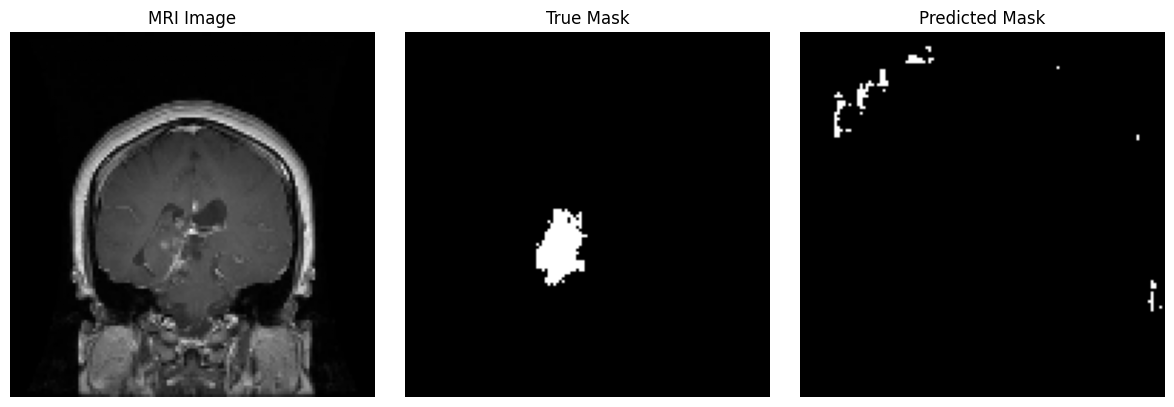

In [ ]:
# Testing Model
# Checks that:
# 1. train_seg_ds works
# 2. seg_cnn_model trains on one tiny batch
# 3. seg_cnn_model can predict a mask

import numpy as np
import matplotlib.pyplot as plt

# Get one batch of images
images, masks = next(iter(train_seg_ds.take(1)))

print("Image batch shape:", images.shape)
print("Mask batch shape:", masks.shape)
print("Mask values:", np.unique(masks.numpy()))

# Train on ONE batch only
history_smoke = seg_cnn_model.fit(
    images,
    masks,
    epochs=1,
    verbose=1
)

# Predict on the same batch
pred_masks = seg_cnn_model.predict(images)

print("Prediction shape:", pred_masks.shape)
print("Prediction range:", pred_masks.min(), "to", pred_masks.max())

# Show one example
i = 0

plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)
plt.imshow(images[i].numpy().squeeze(), cmap="gray")
plt.title("MRI Image")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(masks[i].numpy().squeeze(), cmap="gray")
plt.title("True Mask")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow((pred_masks[i].squeeze() > 0.5), cmap="gray")
plt.title("Predicted Mask")
plt.axis("off")

plt.tight_layout()
plt.show()

In [ ]:
# Running model for basic statistics
import pandas as pd
import numpy as np

# Train briefly on a small number of batches
smoke_history = seg_cnn_model.fit(
    train_seg_ds.take(5),
    validation_data=val_seg_ds.take(2),
    epochs=1,
    verbose=1
)

# Evaluate on a small validation sample
eval_values = seg_cnn_model.evaluate(
    val_seg_ds.take(2),
    verbose=0
)

# Print metric names and values
results = dict(zip(seg_cnn_model.metrics_names, eval_values))

print("\nMini Test Evaluation Results:")
for name, value in results.items():
    print(f"{name}: {value:.4f}")

# Also show it as a small dataframe
display(pd.DataFrame([results]))

5/5 ━━━━━━━━━━━━━━━━━━━━ 11s 97ms/step - binary_accuracy: 0.9838 - dice_coefficient: 0.0302 - loss: 1.6008 - val_binary_accuracy: 0.9810 - val_dice_coefficient: 0.0345 - val_loss: 1.5486

Mini Test Evaluation Results:
loss: 1.5486
compile_metrics: 0.9810


,loss,compile_metrics
0,1.54864,0.980965
